# 04. EDA — Day4

- 04_eda.ipynb — Day4 전체 코드, 계획서 순서(0 → A체인 1~4 → B그룹 5~11)대로 정리
- 중복 셀 정리: 순수 버그수정(display 누락 등)으로 생긴 구버전 셀은 삭제. 방법론이 달라 비교 가치가 있는 구버전(9번 159건, 11번 item_base 기준)은 설명 마크다운과 함께 유지
- 9번 pick_rep(143건 검증) 셀을 섹션 9 안으로 이동(기존엔 섹션 11 뒤에 헤더 없이 떨어져 있었음)
- 실행 결과는 초기화된 상태 — 반영 후 Restart & Run All 한 번 필요
- VSCode/Jupyter의 # %% 구분자 그대로 인식됨.

- 9번 섹션: 159 vs 143 설명 문구 수정(양끝 order_item_id 셀러 비교로 정정) + 검증 셀 순서 수정(pick_rep 다음으로 이동, rep_asc/rep_desc 의존성 오류 해결)

- 4순위 완료: 8번(883건 product_id 실제 검증, 100% 확인), 9번(우편번호/state 검증 — 94.3%/98.7% 동일, distance_km 대표좌표 방식 때문), 7번(normalize 검증 — 영향 없음 확정) + Spearman/Pearson 표기 정리

## 0. 사전 준비 — 폰트·데이터 로드

In [1]:
import pandas as pd
from src import my_qtcheck, my_stats, my_plot

master = pd.read_parquet("data/processed/master.parquet")
item_base = pd.read_parquet("data/processed/item_base.parquet")
assert master["order_id"].is_unique and len(master) == 96204

In [2]:
import matplotlib.pyplot as plt
print(plt.rcParams['font.family'])   # ['Noto Sans KR']이어야 정상 — 아니면 커널 재시작


# ============================================================
# A. 순서 필수 체인 (1 → 4)
# ============================================================

['Noto Sans KR']


## 1. 분석기간 경계 재확인 — 절단편향 관점

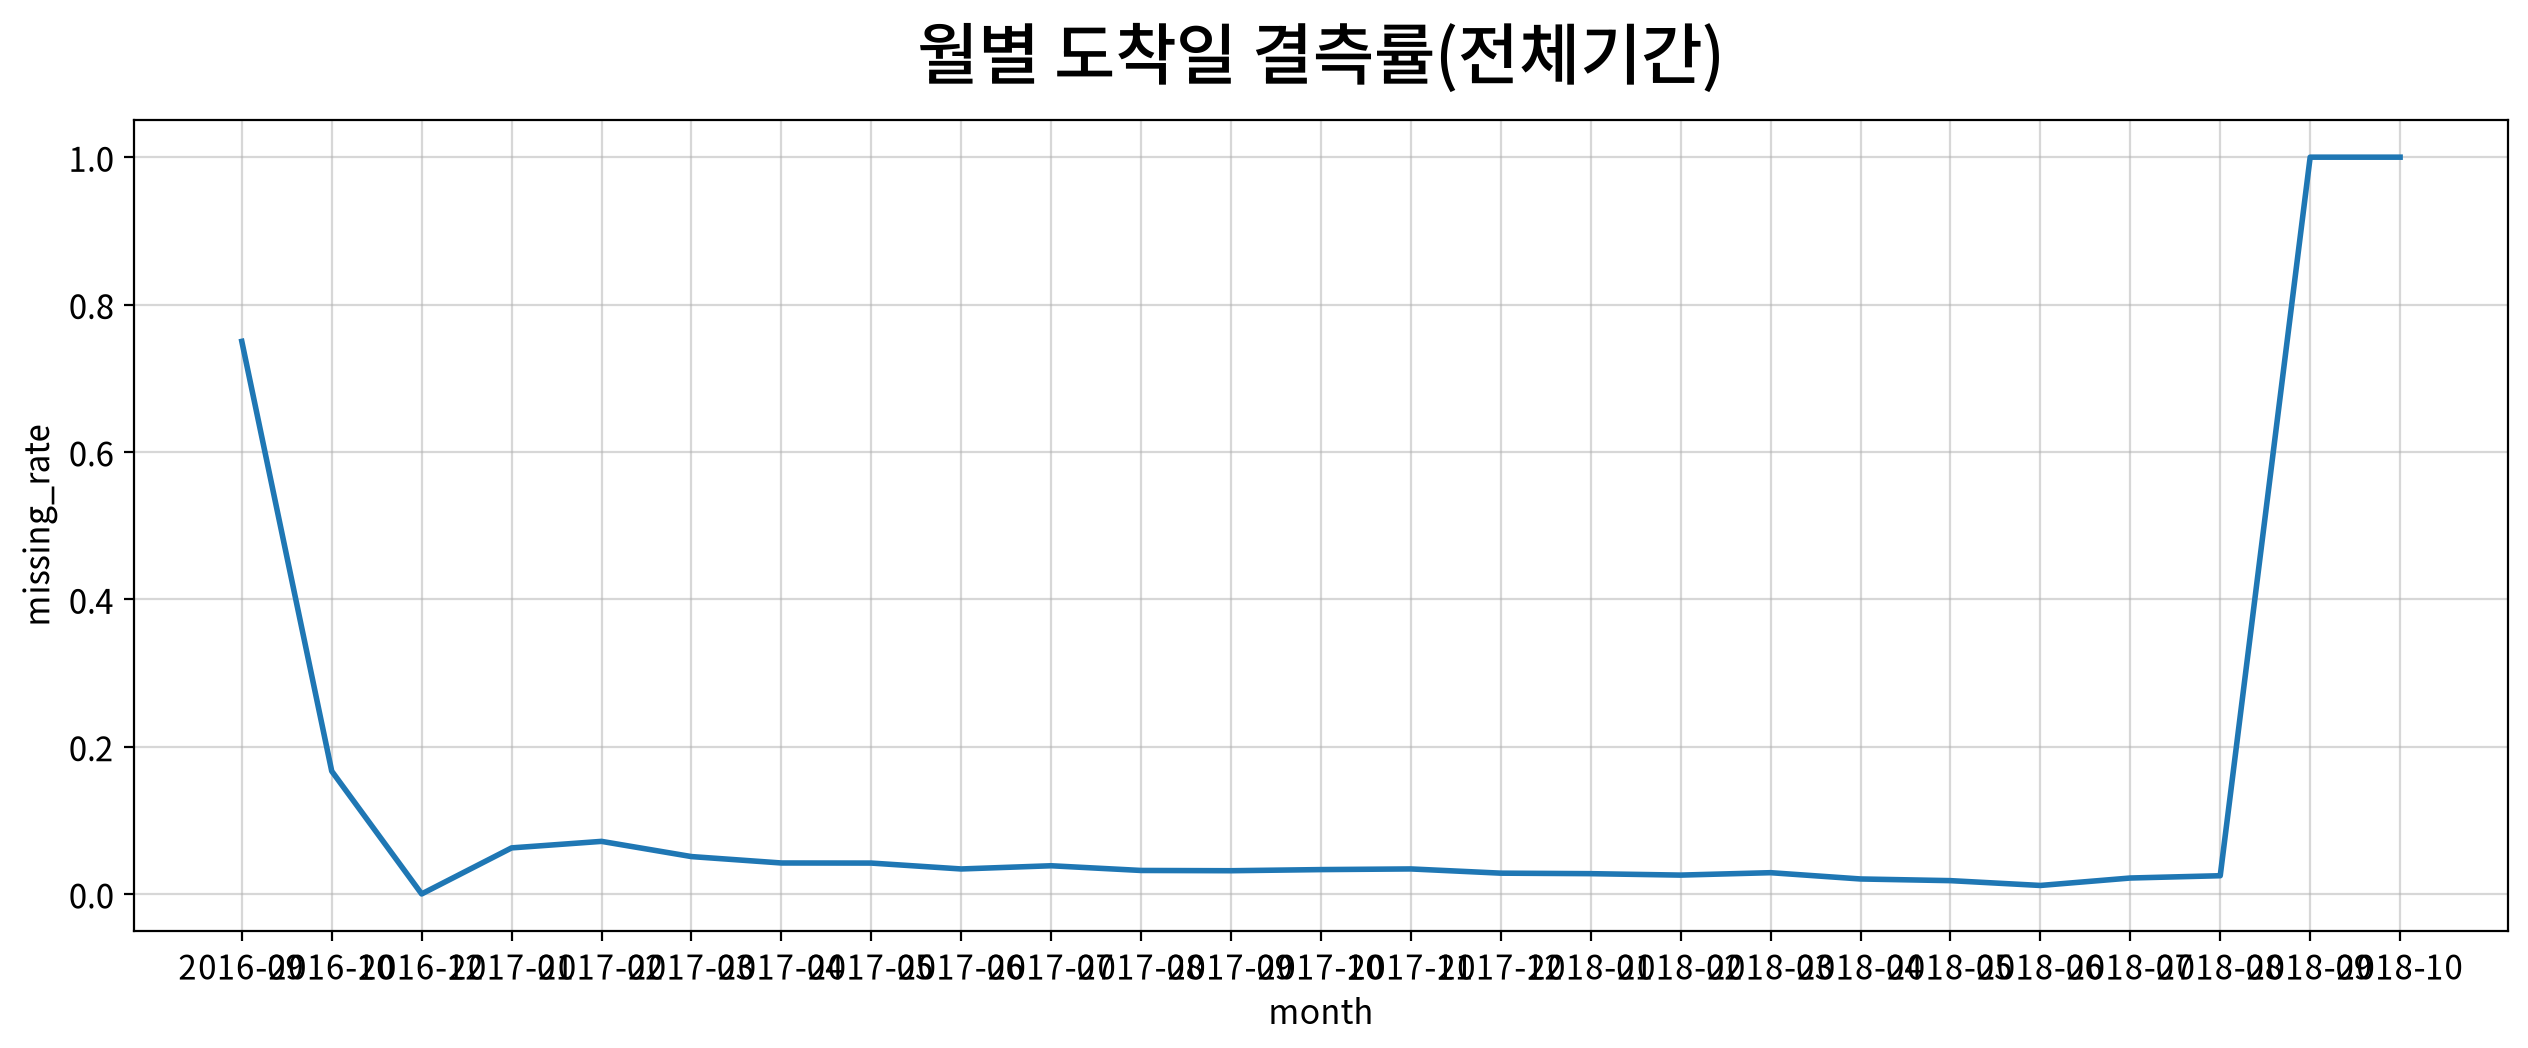

,month,n_orders,n_missing,missing_rate
0,2016-09,4,3,0.750000
1,2016-10,324,54,0.166667
2,2016-12,1,0,0.000000
3,2017-01,800,50,0.062500
4,2017-02,1780,127,0.071348
5,2017-03,2682,136,0.050708
6,2017-04,2404,101,0.042013
7,2017-05,3700,155,0.041892
8,2017-06,3245,110,0.033898
9,2017-07,4026,154,0.038251


In [3]:
orders = pd.read_csv("data/raw/olist_orders_dataset.csv", parse_dates=["order_purchase_timestamp"])

monthly_all = (orders.assign(month=orders.order_purchase_timestamp.dt.to_period("M"))
                      .groupby("month")
                      .agg(n_orders=("order_id", "count"),
                           n_missing=("order_delivered_customer_date", lambda s: s.isna().sum())))
monthly_all["missing_rate"] = monthly_all["n_missing"] / monthly_all["n_orders"]

m1 = monthly_all.reset_index()
m1["month"] = m1["month"].astype(str)
my_plot.lineplot(data=m1, x="month", y="missing_rate", title="월별 도착일 결측률(전체기간)")
m1
# 판단 포인트: 결측률이 경계로 갈수록 "서서히" 오르는지, "특정 달만" 뚝 튀는지
# 서서히 오르면 2018-08도 절단편향 섞였을 가능성 — 관찰만, 원인 추정 금지

## 2. D-03 테스트기간 결정 규칙 — 그래프 보기 전 텍스트로 먼저 고정
(코드 아님 — decisions.md에 그대로 옮겨 적을 규칙 초안)
N/M/X는 지금 숫자로 못 박지 말고 형태만 고정 — 4번에서 실측 후 채움.
특정 월(2017-11 등)을 미리 적지 않기(확증편향 방지).

> D-03 (초안): 월별 지연율·저평점률 추세가 뚜렷하면 마지막 N개월을 테스트로 유지한다.
> 추세 없이 들쭉날쭉하면 M개월로 확장한다.
> 테스트 구간의 late·low 양성 건수가 각각 X건 미만이면 구간을 확장한다.
> (N, M, X는 3번 그래프를 본 뒤 결정하여 decisions.md에 추가 기록)

## 3. 월별 지연율·저평점률 추이

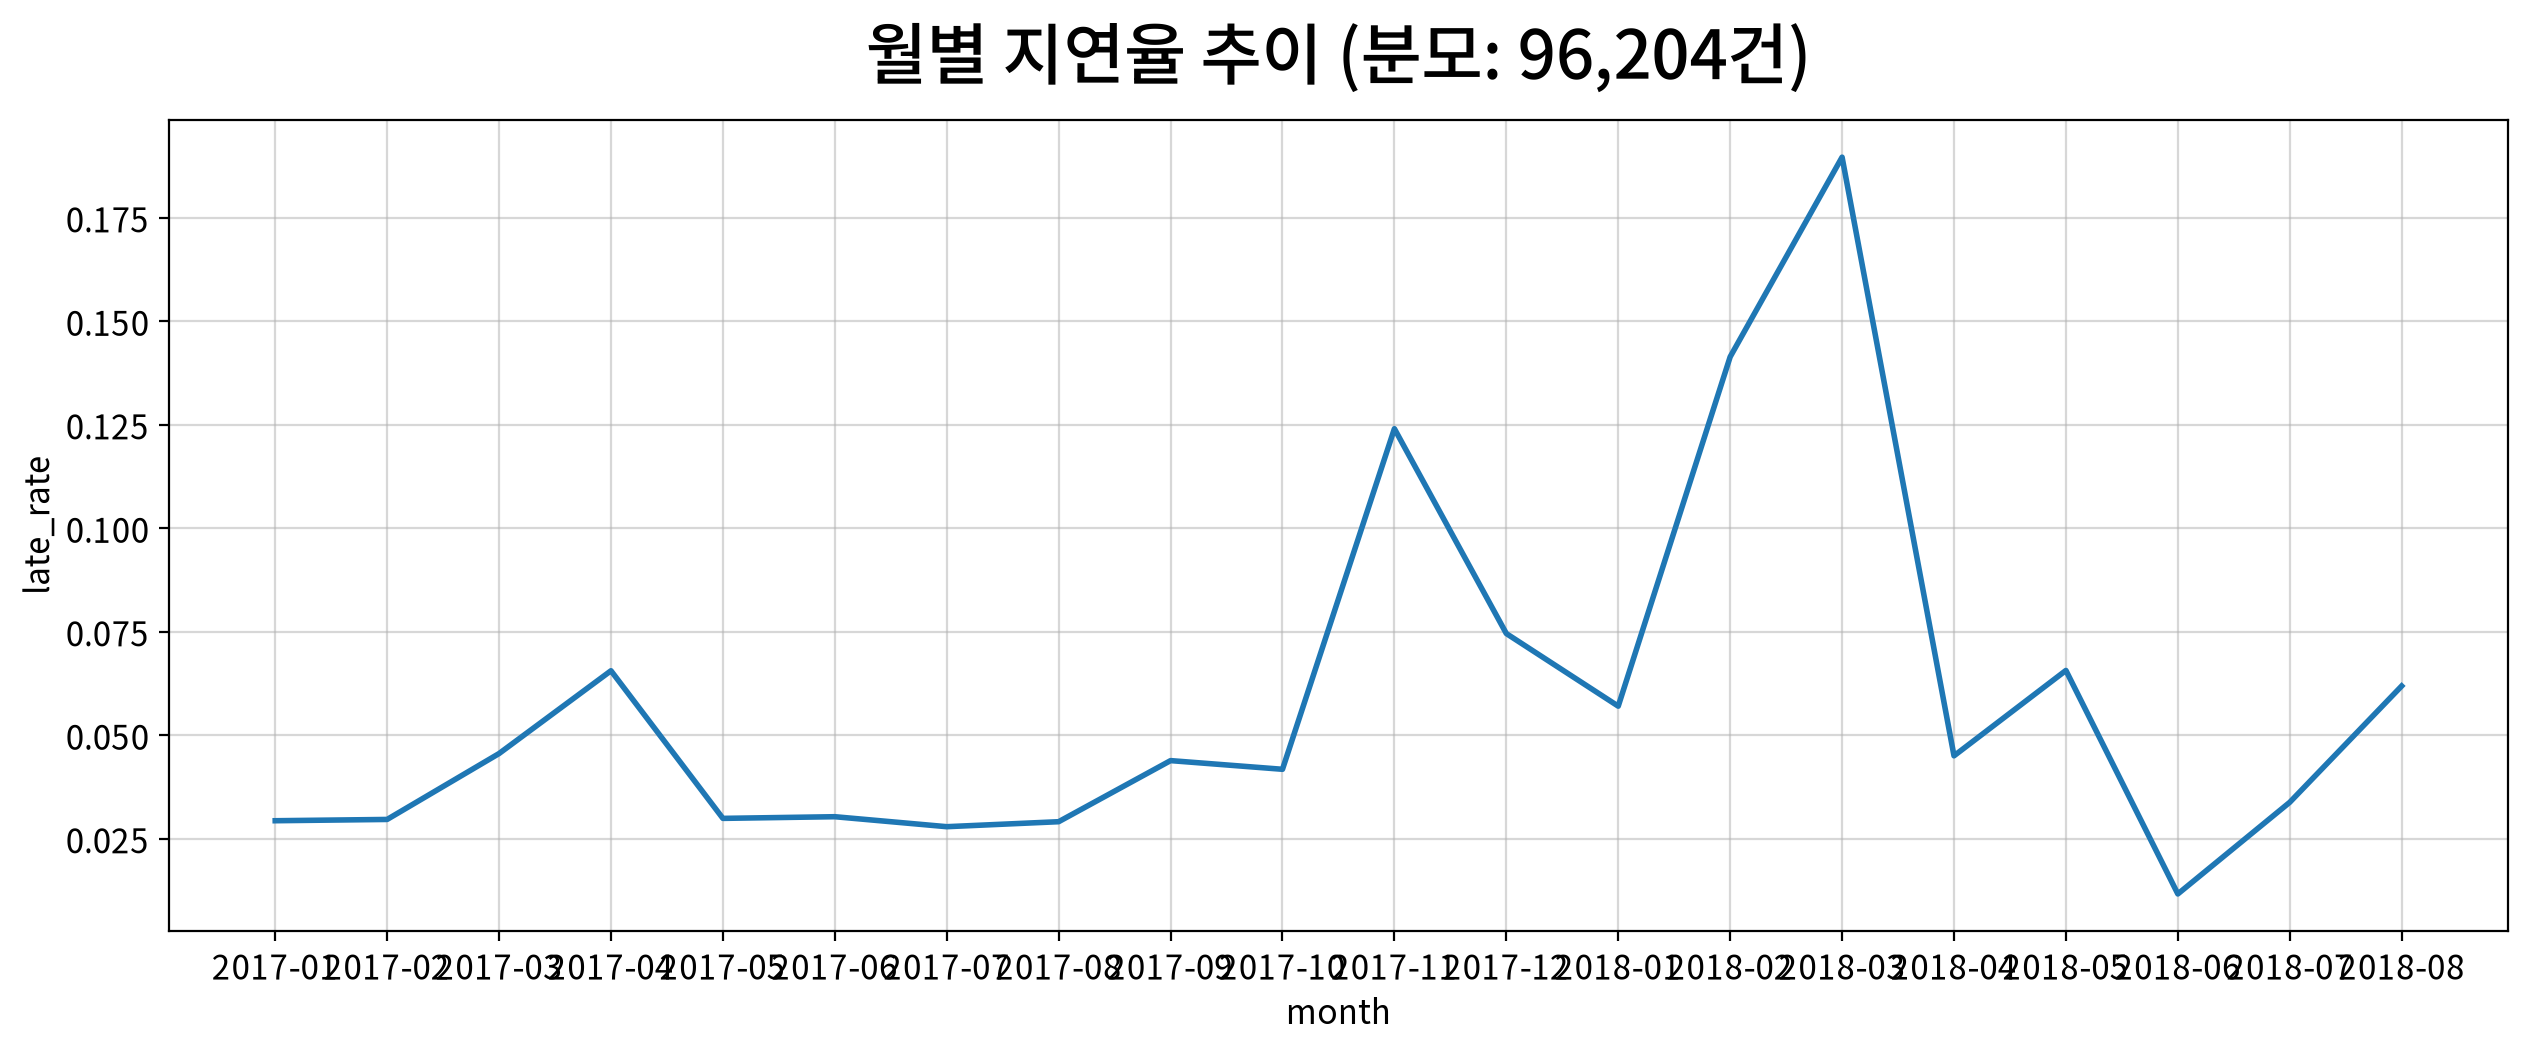

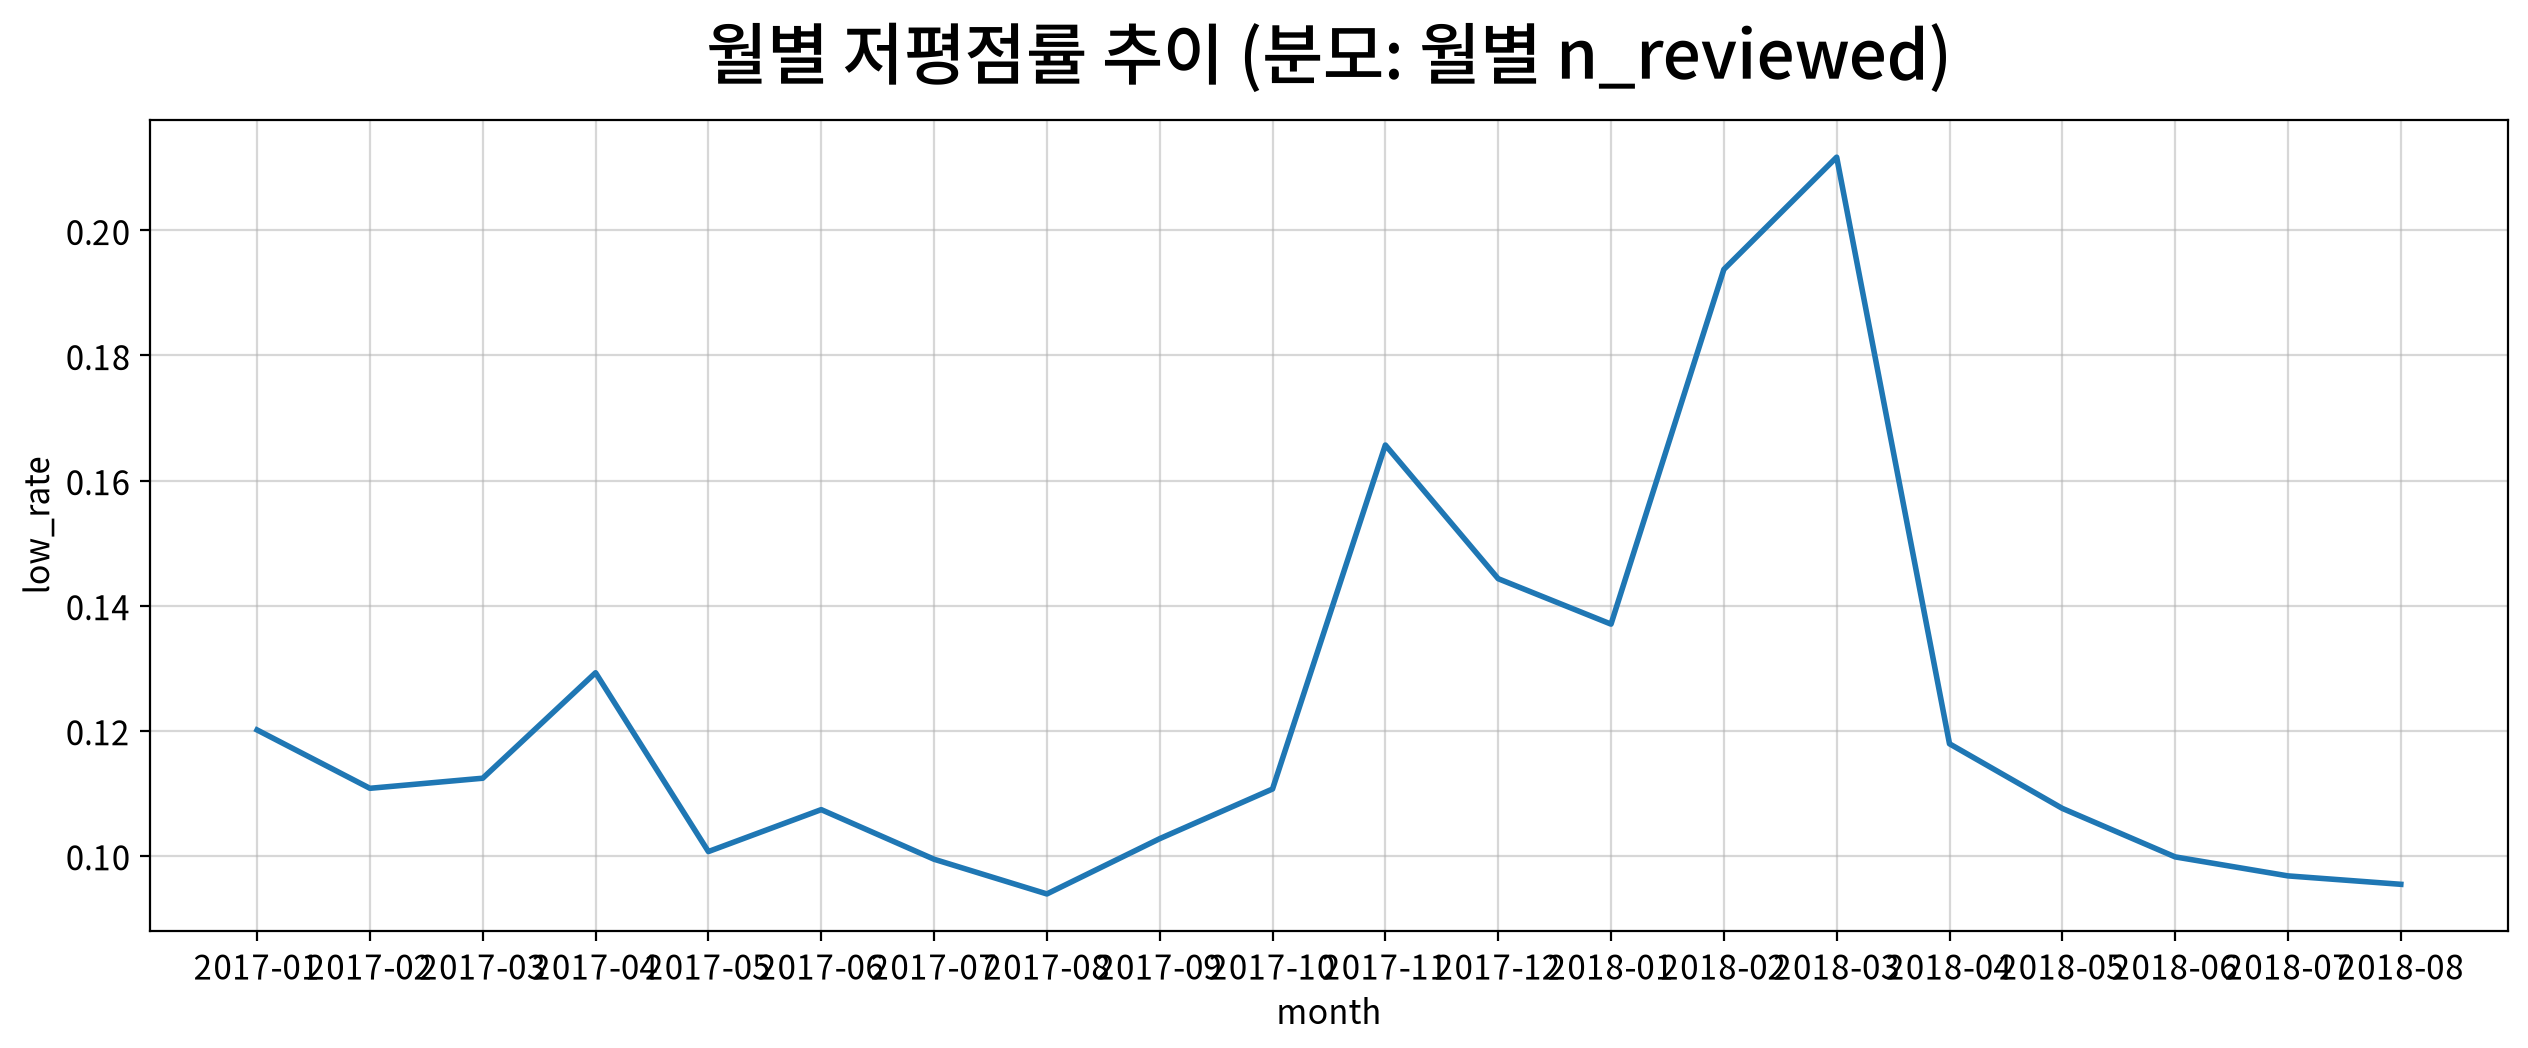

,month,n,late_rate,n_reviewed,low_rate
0,2017-01,750,0.029333,741,0.120108
1,2017-02,1653,0.029643,1643,0.110773
2,2017-03,2546,0.045562,2527,0.112386
3,2017-04,2303,0.065567,2290,0.129258
4,2017-05,3545,0.029901,3517,0.100654
5,2017-06,3135,0.030303,3111,0.107361
6,2017-07,3872,0.027893,3842,0.099427
7,2017-08,4193,0.029096,4165,0.093878
8,2017-09,4150,0.043855,4118,0.102720
9,2017-10,4478,0.041760,4446,0.110661


In [4]:
monthly = (master.assign(month=master.purchase_ts.dt.to_period("M"))
                  .groupby("month")
                  .agg(n=("order_id", "count"),
                       late_rate=("late", "mean"),
                       n_reviewed=("low", "count"),
                       low_rate=("low", "mean")))

m3 = monthly.reset_index()
m3["month"] = m3["month"].astype(str)

my_plot.lineplot(data=m3, x="month", y="late_rate", title="월별 지연율 추이 (분모: 96,204건)")
my_plot.lineplot(data=m3, x="month", y="low_rate", title="월별 저평점률 추이 (분모: 월별 n_reviewed)")
m3
# 관찰로만 기록 — "블랙프라이데이라서" 같은 근거 없는 추측 쓰지 않기

## 4. 잠정 테스트기간 → Y분포 체크 (조건부: 2, 3번 끝난 뒤 N을 채우고 실행)

In [5]:
# B1: 2018-03~08 도착일 결측, order_status별 분리
# (censoring 최악보정에 필요한 범위 전체 — N=4/5/6 후보가 걸치는 달을 다 포함)
target_months = ["2018-03", "2018-04", "2018-05", "2018-06", "2018-07", "2018-08"]
target = orders.assign(month=orders.order_purchase_timestamp.dt.to_period("M").astype(str)) \
               .query("month in @target_months")

missing_by_status = (target[target.order_delivered_customer_date.isna()]
                      .groupby(["month", "order_status"])
                      .size()
                      .rename("n_missing"))
display(missing_by_status)

shipped_by_month = missing_by_status.xs("shipped", level="order_status")
display(shipped_by_month)

# cell5(monthly_all)의 총 결측과 일치하는지 검증
check = missing_by_status.groupby(level=0).sum()
display(check)


month    order_status
2018-03  canceled         26
         invoiced         23
         processing        9
         shipped         133
         unavailable      17
2018-04  canceled         15
         invoiced         14
         processing        8
         shipped          99
         unavailable       5
2018-05  canceled         24
         invoiced         24
         processing        6
         shipped          54
         unavailable      16
2018-06  canceled         18
         delivered         3
         invoiced          3
         shipped          43
         unavailable       4
2018-07  canceled         41
         delivered         3
         invoiced         13
         processing        1
         shipped          60
         unavailable      18
2018-08  canceled         84
         invoiced         23
         shipped          47
         unavailable       7
Name: n_missing, dtype: int64

month
2018-03    133
2018-04     99
2018-05     54
2018-06     43
2018-07     60
2018-08     47
Name: n_missing, dtype: int64

month
2018-03    208
2018-04    141
2018-05    124
2018-06     71
2018-07    136
2018-08    161
Name: n_missing, dtype: int64

In [6]:
# censoring worst-case 보정: shipped(배송중) 결측이 전부 late로 확정된다고 가정했을 때
# N=4/5/6 각각 late율이 얼마나 움직이는지, 전체평균과의 격차 중 몇 %가 해소되는지 비교
overall_rate = master["late"].mean()

for N_try in [4, 5, 6]:
    months = m3["month"].iloc[-N_try:].tolist()
    mask = master["purchase_ts"].dt.to_period("M").astype(str).isin(months)
    n = mask.sum()
    late = master.loc[mask, "late"].sum()
    add = shipped_by_month.reindex(months, fill_value=0).sum()

    raw_rate = late / n
    worst_rate = (late + add) / (n + add)
    gap = overall_rate - raw_rate
    closed = (worst_rate - raw_rate) / gap if gap else float("nan")

    print(f"N={N_try} {months}")
    print(f"  원래 late율: {raw_rate:.4f} / worst-case 보정: {worst_rate:.4f} / shipped결측: {int(add)}건")
    print(f"  전체평균({overall_rate:.4f})과 격차: {gap:+.4f} / censoring으로 해소되는 비율: {closed:.1%}")
    print()


N=4 ['2018-05', '2018-06', '2018-07', '2018-08']
  원래 late율: 0.0440 / worst-case 보정: 0.0516 / shipped결측: 204건
  전체평균(0.0679)과 격차: +0.0239 / censoring으로 해소되는 비율: 31.9%

N=5 ['2018-04', '2018-05', '2018-06', '2018-07', '2018-08']
  원래 late율: 0.0442 / worst-case 보정: 0.0531 / shipped결측: 303건
  전체평균(0.0679)과 격차: +0.0237 / censoring으로 해소되는 비율: 37.7%

N=6 ['2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08']
  원래 late율: 0.0702 / worst-case 보정: 0.0805 / shipped결측: 436건
  전체평균(0.0679)과 격차: -0.0023 / censoring으로 해소되는 비율: -442.5%



**N 최종 결정 (2026-09-23)**

- censoring worst-case 보정: N=4 4.40%→5.16%(격차의 31.8% 해소), N=5 4.42%→5.31%(37.6% 해소), N=6 7.02%→8.05%(오히려 전체평균 6.79%를 초과).
- N=6이 전체평균에 가까웠던 건 안정성 때문이 아니라, 낮은 구간(N=5)과 극단값(2018-03, late_rate 18.96%)이 우연히 상쇄된 결과 — censoring을 최악으로 가정해 보정하면 오히려 평균을 넘어서는 것으로 확인됨. "평균에 가깝다"가 "이 구간이 안정적이다"를 보장하지 않음.
- **N=4(2018-05~08)를 최종 채택**: 극단월이 없고, censoring을 최악으로 가정해도 남는 격차(1.63%p)는 결측 때문이 아니라 실제(real) 변동으로 해석. 다만 테스트 구간의 지연율 자체가 낮아 모델 평가가 유리하게 나올 수 있다는 점은 한계로 남겨 Day5~ 모델링 단계에서 명시.
- 최종 테스트 구간: 2018-05~08, late 1,115건 / low 2,525건 — 최소 기준(X건) 충분히 통과.

In [7]:
N = 4  # D-03 최종 확정(2026-09-23): censoring worst-case 보정해도 N=6은 전체평균을 초과, N=4가 극단월 없는 안정 구간

test_months = m3["month"].iloc[-N:].tolist()
test_mask = master["purchase_ts"].dt.to_period("M").astype(str).isin(test_months)

test_late = master.loc[test_mask, "late"].sum()
test_low  = master.loc[test_mask, "low"].sum()

print(f"최종 테스트 구간: {test_months}")
print(f"late 양성: {test_late}건 / low 양성: {test_low}건")


최종 테스트 구간: ['2018-05', '2018-06', '2018-07', '2018-08']
late 양성: 1115건 / low 양성: 2525.0건


In [8]:
for N_try in [2, 3, 4, 6]:
    months = m3["month"].iloc[-N_try:].tolist()
    mask = master["purchase_ts"].dt.to_period("M").astype(str).isin(months)
    print(N_try, months, master.loc[mask,"late"].sum(), master.loc[mask,"low"].sum())

2 ['2018-07', '2018-08'] 601 1196.0
3 ['2018-06', '2018-07', '2018-08'] 672 1802.0
4 ['2018-05', '2018-06', '2018-07', '2018-08'] 1115 2525.0
6 ['2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08'] 2749 4792.0


## 5. Y 분포 재확인 + 선택편향 정식 카이제곱

In [9]:
display(master.late.value_counts(normalize=True))
display(master.low.value_counts(dropna=False, normalize=True))
display(pd.crosstab(master.late, master.low, dropna=False))
# late 6,532건(6.79%) / low 12,228건(12.8%) / 3단계 대상 8,247건 — Day1~3 수치와 일치 확인됨

late
0    0.932103
1    0.067897
Name: proportion, dtype: float64

low
0.0    0.866211
1.0    0.127105
NaN    0.006684
Name: proportion, dtype: float64

low,0.0,1.0,NaN
late,,,
0,80935,8247,490
1,2398,3981,153


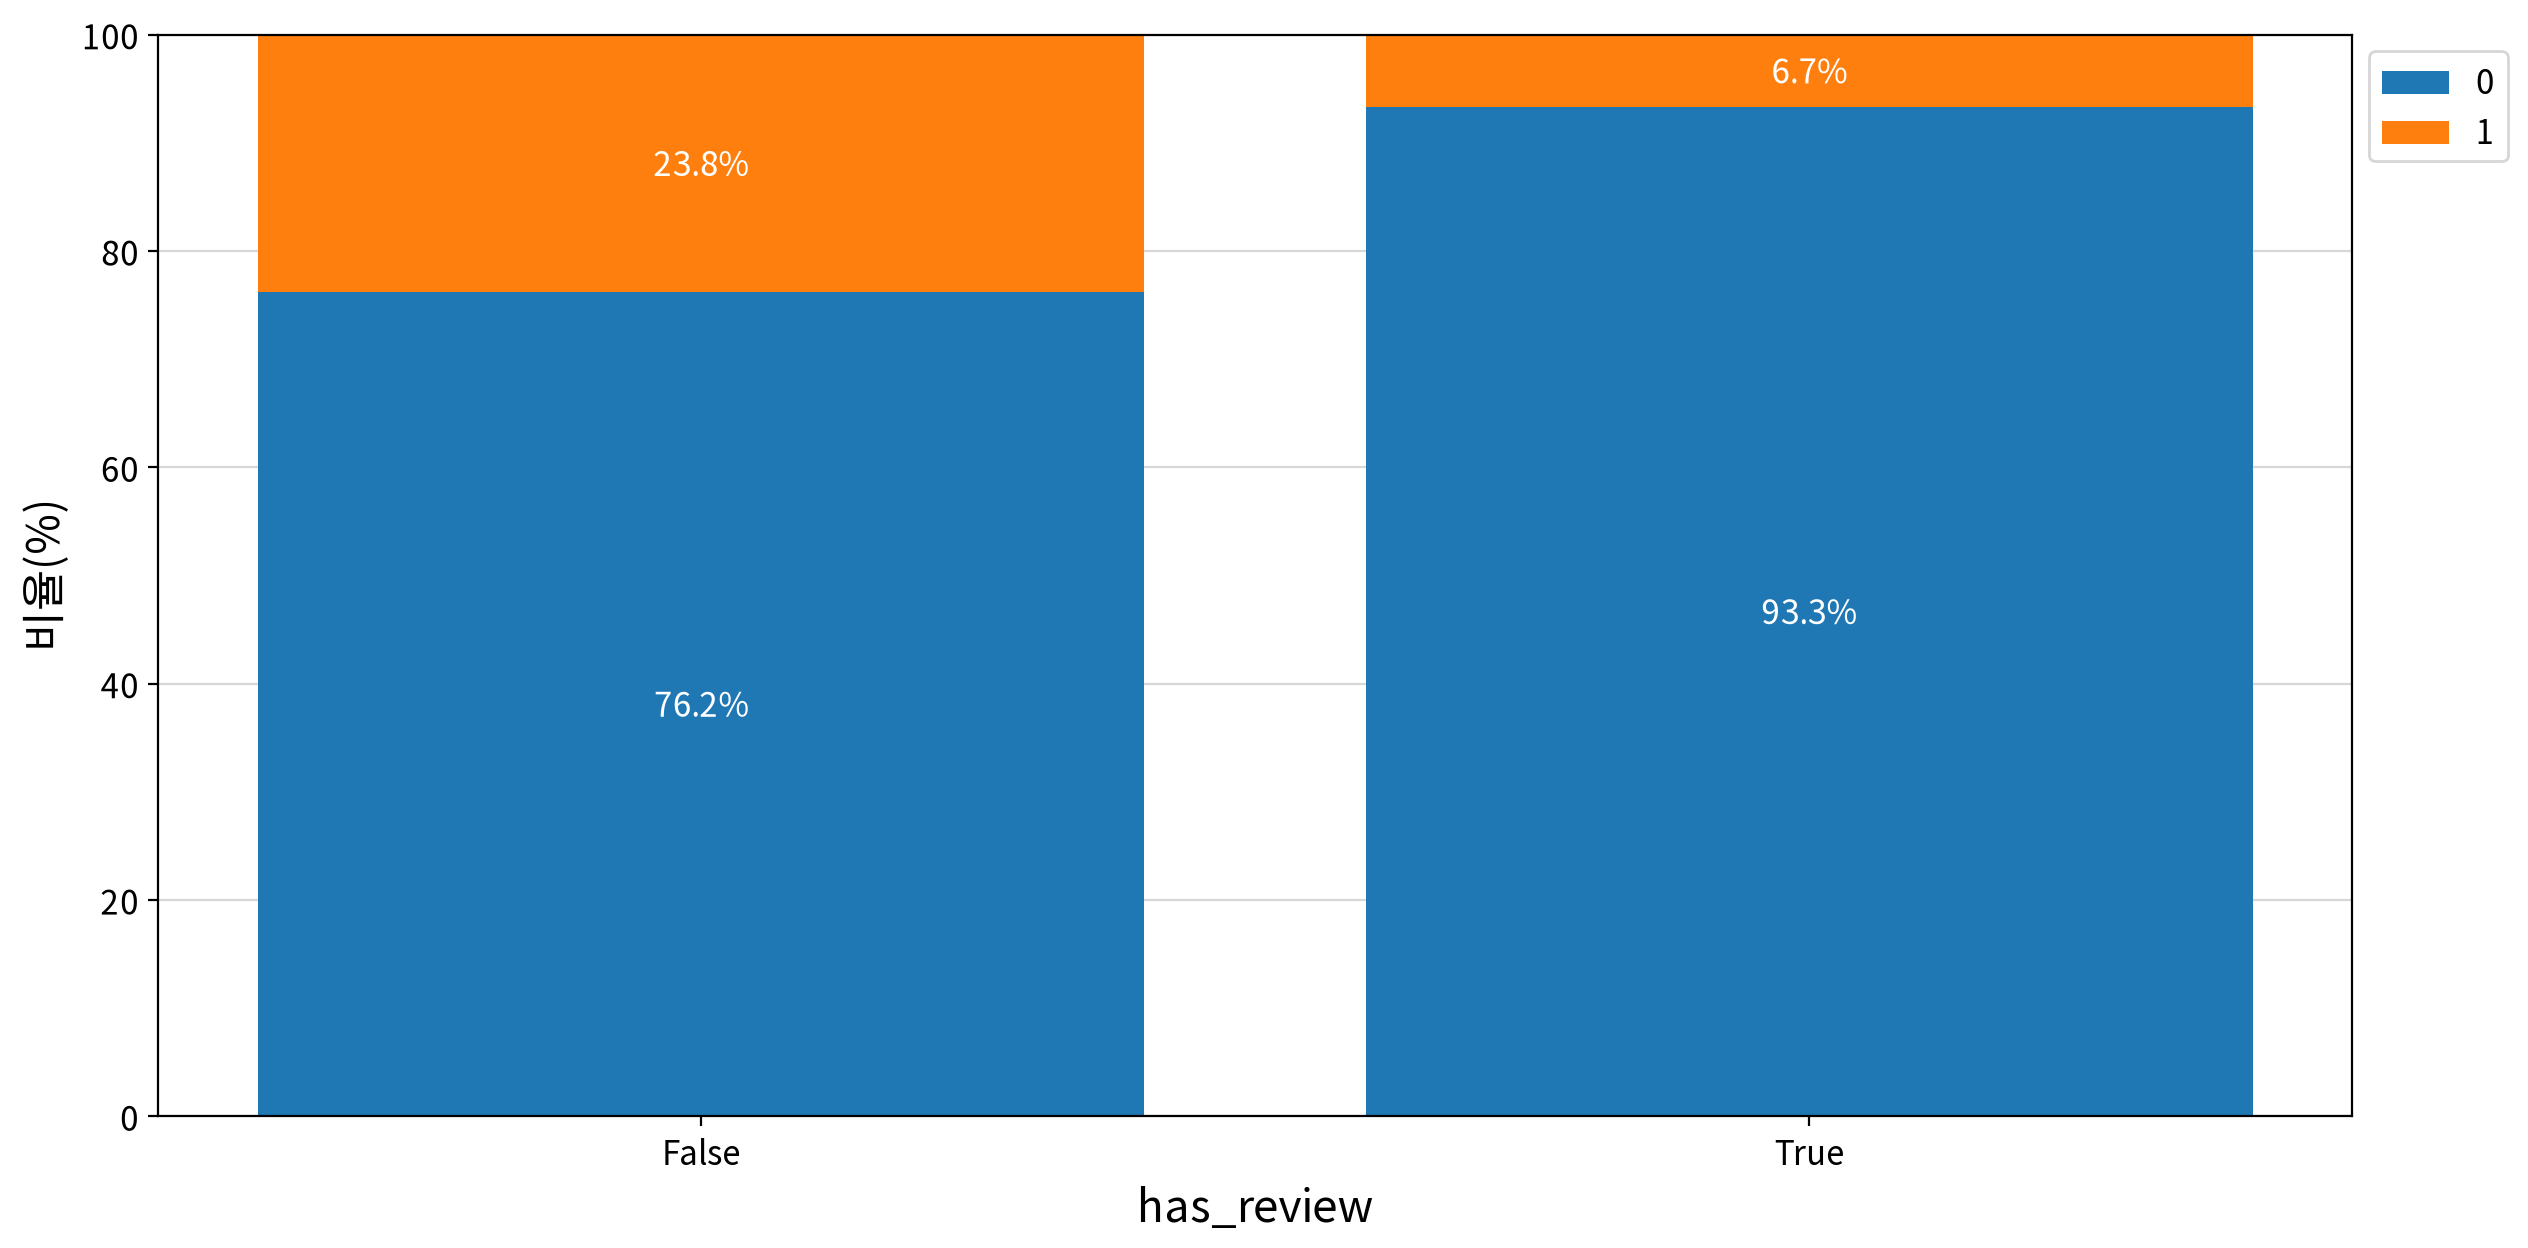

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
has_review,late,Chi-square test of independence,293.0742,1,0.0,True,0.0552,Negligible,43.66,True


In [10]:
tmp = master.assign(has_review=master.low.notna())
my_stats.chi2_independence(tmp, x="has_review", y="late")
# 실행 확인됨: chi2=293.07, p<.001, Cramer's V=0.055(negligible)

## 6. 카테고리 '미상'(1,376건) 비교

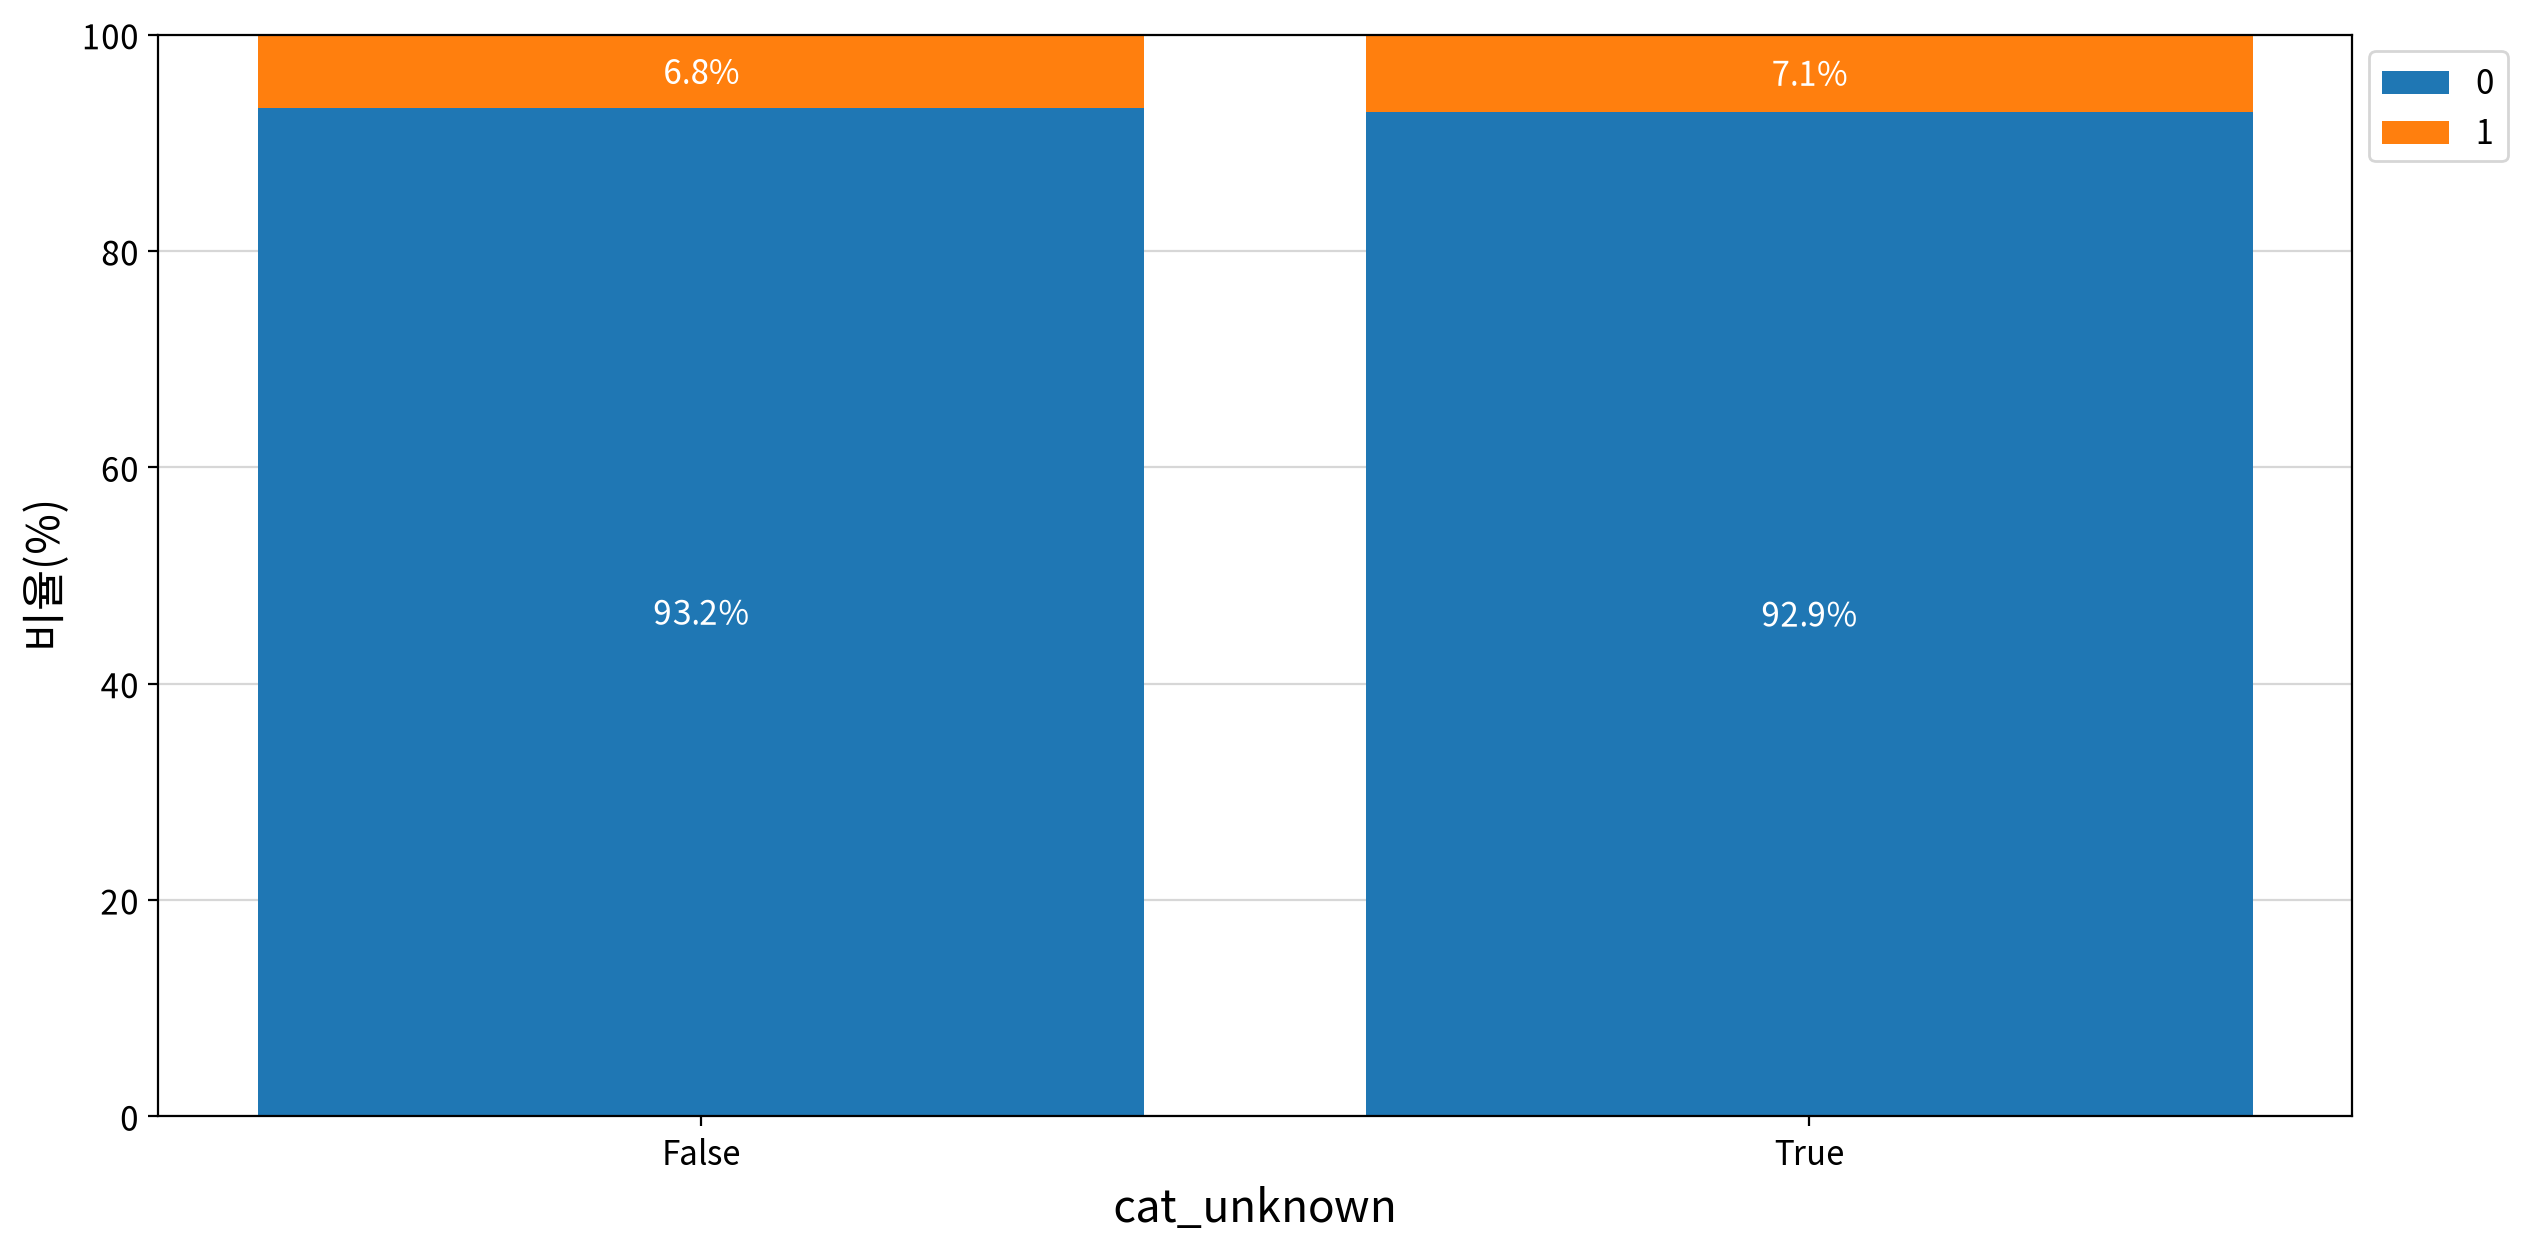

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
cat_unknown,late,Chi-square test of independence,0.1933,1,0.660199,False,0.0014,Negligible,93.43,True


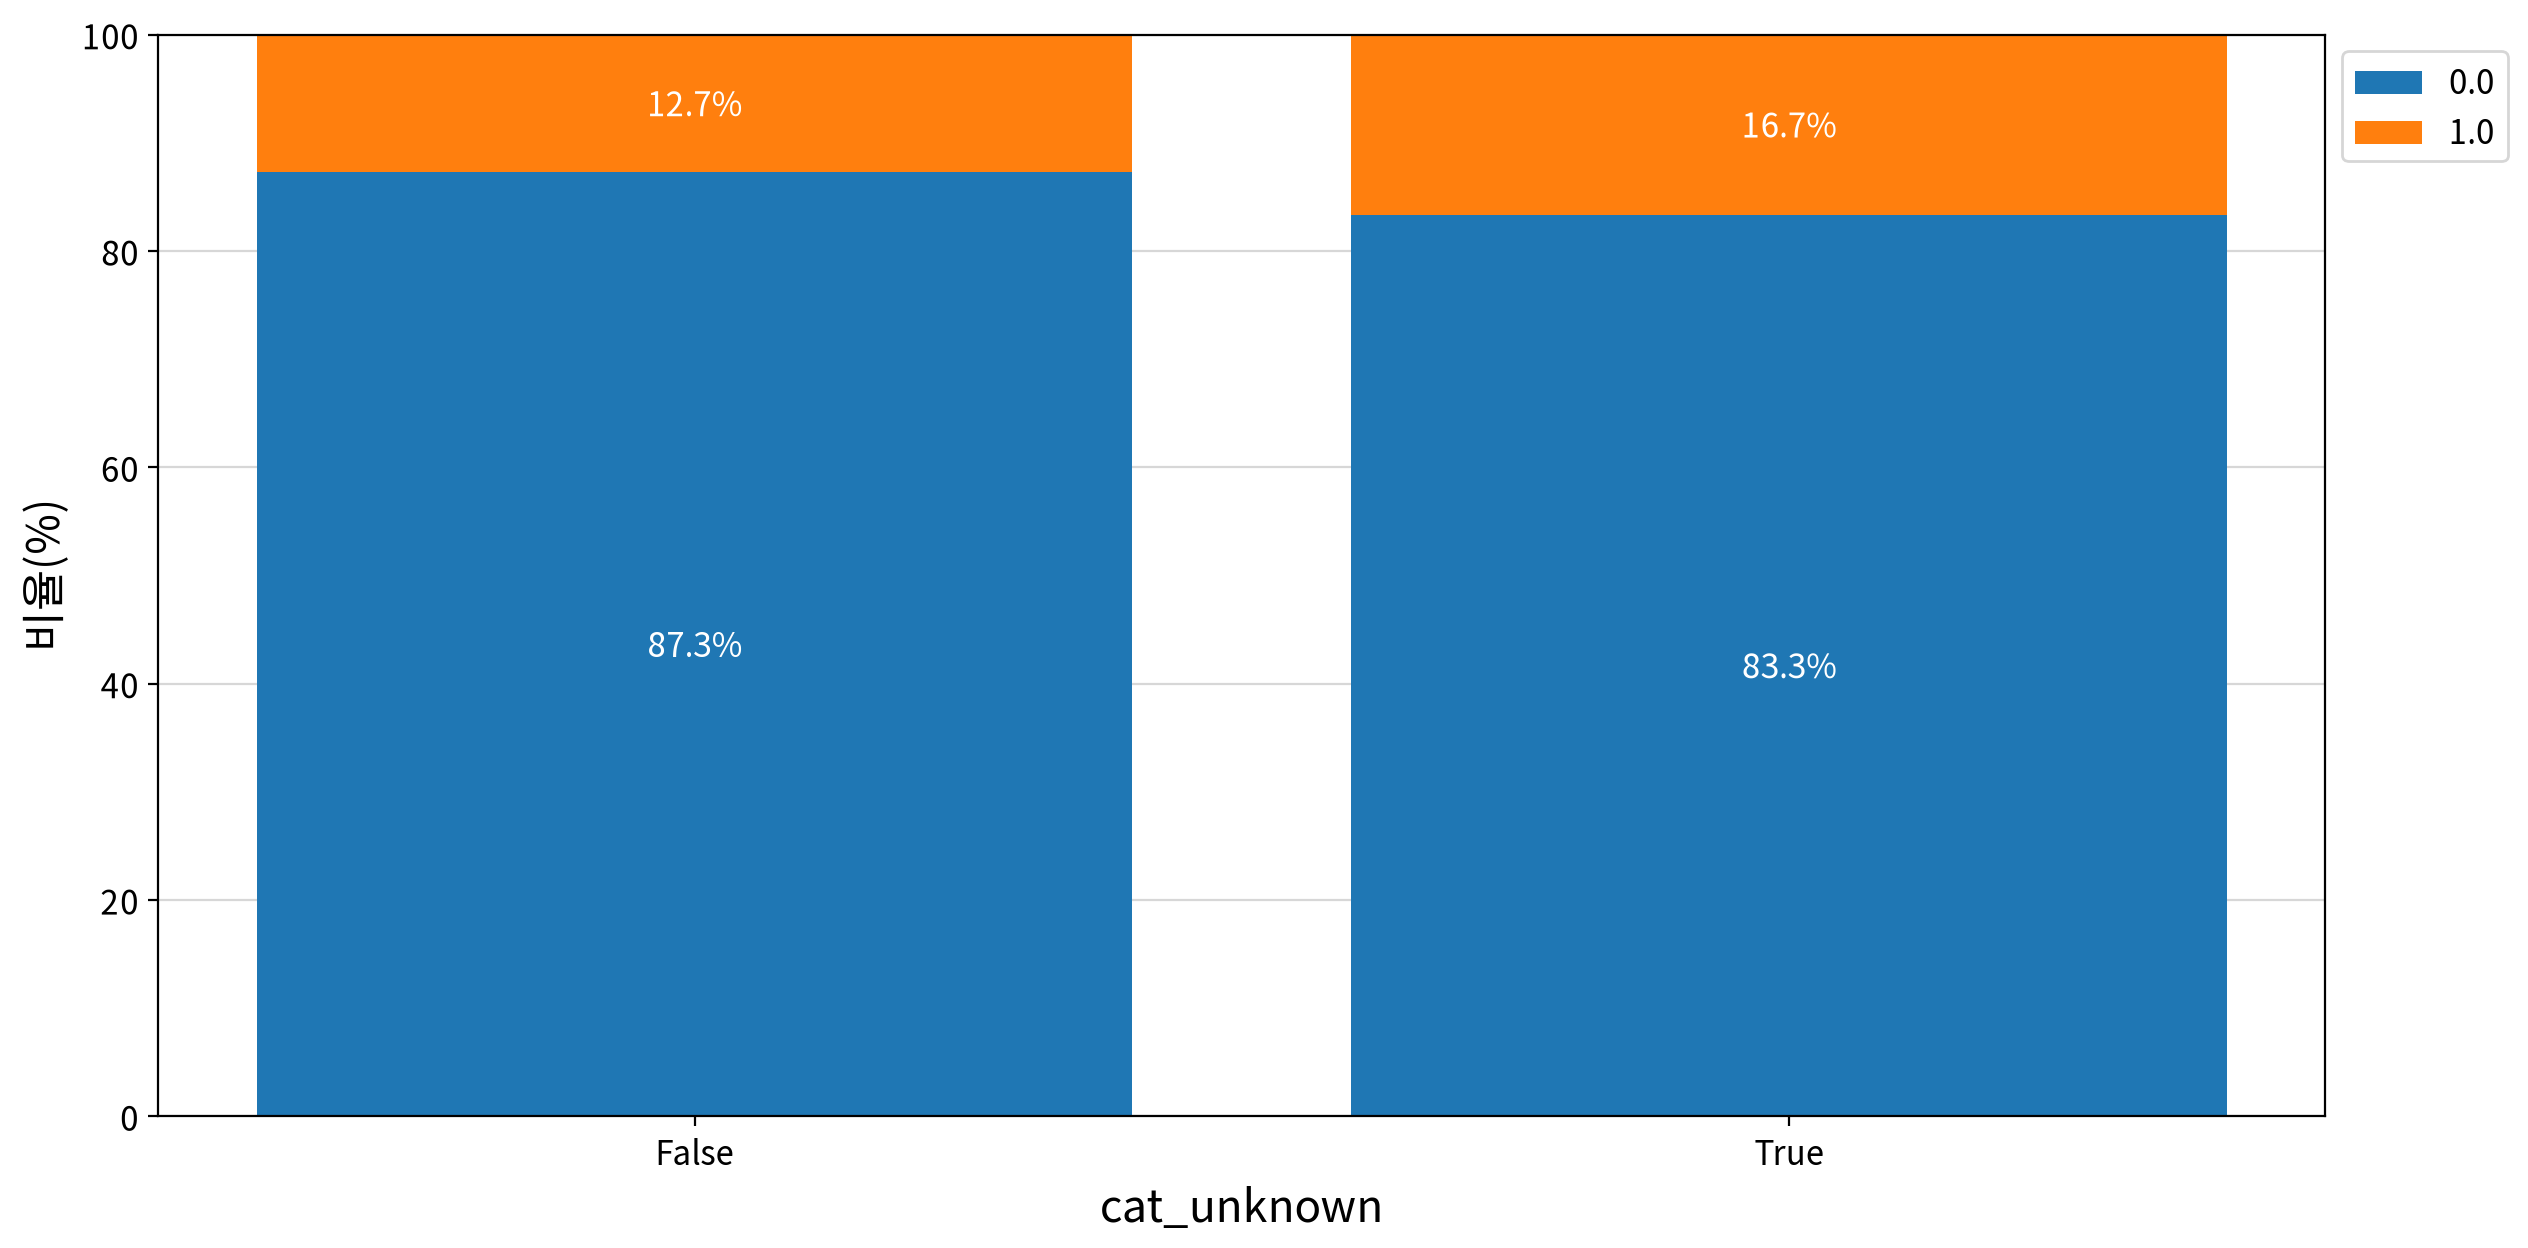

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
cat_unknown,low,Chi-square test of independence,18.3863,1,0.000018,True,0.0139,Negligible,174.92,True


In [11]:
m = master.assign(cat_unknown=master.category_en == "미상")
display(my_stats.chi2_independence(m, x="cat_unknown", y="late"))
display(my_stats.chi2_independence(m, x="cat_unknown", y="low"))
# cat_unknown×late — chi2=0.19, p=0.660, 유의하지 않음, V=0.0014
# cat_unknown×low  — chi2=18.39, p<.001, 유의함(효과크기는 negligible)

## 7. 분석기간 기준 상관계수 재계산

In [12]:
master["delivery_error_days"] = (master.order_delivered_customer_date - master.order_estimated_delivery_date).dt.days
master["expected_lead_days"]  = (master.order_estimated_delivery_date - master.purchase_ts).dt.days

my_stats.multi_correlation(master,
    columns=["delivery_error_days", "expected_lead_days", "distance_km", "price_sum", "freight_sum", "installments_max"],
    plot=False)   # 15쌍 검정 + pairplot은 무거우니 숫자표만 먼저
# EDA 전용 파생 — 모델 입력 금지(data_dictionary.md)
# 계획서 기준값(전체기간 -0.50/0.52)과 비교, 차이는 "전체 vs 분석기간 차이"로만 기록(원인추정 X)
# 실행 확인됨 (Spearman 자동 사용 — my_stats.correlation() 소스 확인: 정규성/선형성/영향점/왜도
#   중 하나라도 위반하면 Spearman으로 자동 전환. delivery_error_days는 분포 특성상 조건 위반 추정)
# 계획서 원문(-0.50/0.52)은 Pearson으로 추정 — 계수 종류가 달라 직접 비교는 참고용

,delivery_error_days,expected_lead_days,distance_km,price_sum,freight_sum,installments_max
delivery_error_days,1.000,-0.564,-0.183,-0.043,-0.156,-0.053
expected_lead_days,-0.564,1.000,0.622,0.120,0.460,0.094
distance_km,-0.183,0.622,1.000,0.114,0.588,0.099
price_sum,-0.043,0.120,0.114,1.000,0.469,0.375
freight_sum,-0.156,0.460,0.588,0.469,1.000,0.231
installments_max,-0.053,0.094,0.099,0.375,0.231,1.000


method    coef  p-value  strength  \
x                   y                                                         
delivery_error_days expected_lead_days  Spearman -0.5635      0.0  Moderate   
                    distance_km         Spearman -0.1827      0.0      Weak   
                    price_sum           Spearman -0.0434      0.0      Weak   
                    freight_sum         Spearman -0.1557      0.0      Weak   
                    installments_max    Spearman -0.0535      0.0      Weak   
expected_lead_days  distance_km         Spearman  0.6220      0.0  Moderate   
                    price_sum           Spearman  0.1205      0.0      Weak   
                    freight_sum         Spearman  0.4598      0.0  Moderate   
                    installments_max    Spearman  0.0944      0.0      Weak   
distance_km         price_sum           Spearman  0.1135      0.0      Weak   
                    freight_sum         Spearman  0.5884      0.0  Moderate   
                    installments_max    Spearman  0.0987      0.0      Weak   
price_sum           freight_sum         Spearman  0.4695      0.0  Moderate   
                    installments_max    Spearman  0.3747      0.0  Moderate   
freight_sum         installments_max    Spearman  0.2311      0.0      Weak   

                                        significant  normality_x  normality_y  \
x                   y                                                           
delivery_error_days expected_lead_days         True        False        False   
                    distance_km                True        False        False   
                    price_sum                  True        False        False   
                    freight_sum                True        False        False   
                    installments_max           True        False        False   
expected_lead_days  distance_km                True        False        False   
                    price_sum                  True        False        False   
                    freight_sum                True        False        False   
                    installments_max           True        False        False   
distance_km         price_sum                  True        False        False   
                    freight_sum                True        False        False   
                    installments_max           True        False        False   
price_sum           freight_sum                True        False        False   
                    installments_max           True        False        False   
freight_sum         installments_max           True        False        False   

                                        linearity  influential_outlier  \
x                   y                                                    
delivery_error_days expected_lead_days      False                False   
                    distance_km             False                False   
                    price_sum               False                False   
                    freight_sum             False                False   
                    installments_max        False                False   
expected_lead_days  distance_km             False                False   
                    price_sum               False                False   
                    freight_sum             False                 True   
                    installments_max        False                False   
distance_km         price_sum               False                False   
                    freight_sum             False                 True   
                    installments_max        False                False   
price_sum           freight_sum             False                 True   
                    installments_max        False                False   
freight_sum         installments_max        False                False   

                                        high_skew  
x        

In [13]:
# normalize 검증 — .dt.days vs .dt.normalize() 적용 전후 비교
delivery_error_raw = (master.order_delivered_customer_date - master.order_estimated_delivery_date).dt.days
delivery_error_norm = (master.order_delivered_customer_date.dt.normalize()
                        - master.order_estimated_delivery_date.dt.normalize()).dt.days

diff = (delivery_error_raw - delivery_error_norm).dropna()
print("두 방식이 다른 행 수:", (diff != 0).sum(), "/", len(diff))
print("차이 분포:", diff.value_counts().sort_index())

import numpy as np
mask = master["delivery_error_days"].notna() & master["expected_lead_days"].notna()
r_raw  = np.corrcoef(delivery_error_raw[mask],  master.loc[mask, "expected_lead_days"])[0,1]
r_norm = np.corrcoef(delivery_error_norm[mask], master.loc[mask, "expected_lead_days"])[0,1]

print(f"raw(.dt.days) 상관계수:       {r_raw:.4f}")
print(f"normalize 적용 상관계수:      {r_norm:.4f}")
print(f"차이: {abs(r_raw - r_norm):.4f}")
# 실행 확인됨: 두 방식이 다른 행 수 0/96204 — 두 datetime 모두 시간정보 없음(전부 00:00:00)
#   상관계수 차이 0.0000 — normalize 불필요, 기존 .dt.days 코드 그대로 유지

두 방식이 다른 행 수: 0 / 96204
차이 분포: 0    96204
Name: count, dtype: int64
raw(.dt.days) 상관계수:       -0.4885
normalize 적용 상관계수:      -0.4885
차이: 0.0000


## 8. 가격 동점 주문(7,431건) 원인 — 가설 3개

In [14]:
order_max_price = item_base.groupby("order_id")["price"].transform("max")
is_max = item_base["price"] == order_max_price

tie_count = item_base[is_max].groupby("order_id").size()
tie_orders = tie_count[tie_count > 1].index
print(f"가격 동점 주문 수: {len(tie_orders)}건")

tie_items = item_base[item_base["order_id"].isin(tie_orders) & is_max]
items_per_order = item_base.groupby("order_id").size()

hyp_a = items_per_order.loc[tie_orders].eq(1).sum()
hyp_b = tie_items.groupby("order_id")["price"].apply(lambda s: (s == 0).all()).sum()
hyp_c = tie_items.groupby("order_id")["product_id"].nunique().eq(1).sum()

print(f"(a) 아이템 1개인데 동점(버그 의심): {hyp_a}건")
print(f"(b) 가격 0원 여러 개: {hyp_b}건")
print(f"(c) 같은 product_id 여러 개(정상 예상): {hyp_c}건")
print(f"미분류: {len(tie_orders) - hyp_a - hyp_b - hyp_c}건")
# 실행 확인됨: 7431건 / (a)0 / (b)0 / (c)6548 / 미분류883
# 미분류 883건 검증 완료 — 전부 product_id가 실제로 다른, 우연한 가격 동일 케이스 (100% 확인, 아래 셀)
# 미분류 883건은 "다른 상품 우연 동가"로 추정 — log.md에 메모

가격 동점 주문 수: 7431건
(a) 아이템 1개인데 동점(버그 의심): 0건
(b) 가격 0원 여러 개: 0건
(c) 같은 product_id 여러 개(정상 예상): 6548건
미분류: 883건


In [15]:
# 미분류 883건 실제 검증 — 정말 "다른 product_id가 우연히 같은 가격"인지 확인
hyp_b_mask = tie_items.groupby("order_id")["price"].apply(lambda s: (s == 0).all())
hyp_c_mask = tie_items.groupby("order_id")["product_id"].nunique().eq(1)

hyp_b_orders = hyp_b_mask[hyp_b_mask].index
hyp_c_orders = hyp_c_mask[hyp_c_mask].index

unclassified_orders = tie_orders.difference(hyp_b_orders).difference(hyp_c_orders)
print("미분류 건수:", len(unclassified_orders), "(기대: 883)")

n_diff_product = (tie_items[tie_items["order_id"].isin(unclassified_orders)]
                   .groupby("order_id")["product_id"].nunique().gt(1).sum())
print("미분류 중 product_id 실제로 다른 주문:", n_diff_product, "/", len(unclassified_orders))

sample = tie_items[tie_items["order_id"].isin(unclassified_orders[:5])]
sample.sort_values(["order_id", "price"])[["order_id", "product_id", "price"]]
# 실행 확인됨: 미분류 883/883, product_id 실제로 다른 주문 883/883 — 100% 검증 완료

미분류 건수: 883 (기대: 883)
미분류 중 product_id 실제로 다른 주문: 883 / 883


,order_id,product_id,price
89,00337fe25a3780b3424d9ad7c5a4b35e,1f9799a175f50c9fa725984775cac5c5,59.90
90,00337fe25a3780b3424d9ad7c5a4b35e,13944d17b257432717fd260e69853140,59.90
211,00946f674d880be1f188abc10ad7cf46,4dcb49b9ca7e48d2f108d40caa77caa2,99.90
212,00946f674d880be1f188abc10ad7cf46,9bb2d066e4b33b624cbdfec7d50b3dcb,99.90
476,01235dc626dcf13283207ba7f36a959a,176faef125e3675b4eeaa6083ada61e1,25.99
477,01235dc626dcf13283207ba7f36a959a,10dae91e0aba95747e90280edeffe883,25.99
486,012a238ab54294a3b365812ccc82b135,07c055536ebf10dfbb6c6db6dbfc36e5,45.90
487,012a238ab54294a3b365812ccc82b135,741a31499a578979be85db7f80139e62,45.90
488,012a238ab54294a3b365812ccc82b135,8338cef8355d238f43711dcb9c0657b2,45.90
503,0132451f29a10b66a5cf1bacc85f9afe,42a2bd596fda1baef5719cb74f73030c,89.90


## 9. distance_km 유니크 값 · 거리동점(143건) 구성 — 수정판
(멀티셀러 주문만 대상 — 단일셀러는 seller_rep 선택에 애매함이 없음)

In [16]:
print("distance_km 유니크 값 개수:", item_base["distance_km"].nunique())

seller_per_order = item_base.groupby("order_id")["seller_id"].nunique()
multi_seller_orders = seller_per_order[seller_per_order > 1].index
mb = item_base[item_base["order_id"].isin(multi_seller_orders)]

all_null_multi = mb.groupby("order_id")["distance_km"].apply(lambda s: s.isna().all())
all_null_multi = all_null_multi[all_null_multi].index
print("멀티셀러 & 거리 전부 NULL:", len(all_null_multi), "건 (기대: 6건)")

order_max_dist = mb.groupby("order_id")["distance_km"].transform("max")
is_max_dist = mb["distance_km"] == order_max_dist
max_items = mb[is_max_dist]
seller_count = max_items.groupby("order_id")["seller_id"].nunique()
tie_orders_dist = seller_count[seller_count > 1].index
print("멀티셀러 & 거리 동점:", len(tie_orders_dist), "건")

print("합계(기대: 143건):", len(tie_orders_dist) + len(all_null_multi))

sample = max_items[max_items["order_id"].isin(tie_orders_dist[:5])]
sample.sort_values(["order_id", "order_item_id"])[["order_id", "order_item_id", "seller_id", "distance_km"]]
# 159건 = "느슨한 조건"(동점 후보). 143건과 다른 이유는 다음 마크다운 참고

distance_km 유니크 값 개수: 91107
멀티셀러 & 거리 전부 NULL: 6 건 (기대: 6건)
멀티셀러 & 거리 동점: 153 건
합계(기대: 143건): 159


,order_id,order_item_id,seller_id,distance_km
1198,02e405aa2667a116637cdb4affaf93c0,1,640e21a7d01df7614a3b4923e990d40c,421.676773
1199,02e405aa2667a116637cdb4affaf93c0,2,391fc6631aebcf3004804e51b40bcf1e,421.676773
3119,0758015124a0c9af755d31a7bf0efedc,1,1900267e848ceeba8fa32d80c1a5f5a8,829.236343
3120,0758015124a0c9af755d31a7bf0efedc,2,b39d7fe263ef469605dbb32608aee0af,829.236343
4256,0a0090ae69392fa38ee742006f8c0a90,1,4a3ca9315b744ce9f8e9374361493884,316.493660
4257,0a0090ae69392fa38ee742006f8c0a90,2,d20b021d3efdf267a402c402a48ea64b,316.493660
5436,0ccc28cc32fa5c8ca6a3b2d594700714,1,cca3071e3e9bb7d12640c9fbe2301306,411.992429
5437,0ccc28cc32fa5c8ca6a3b2d594700714,2,4a3ca9315b744ce9f8e9374361493884,411.992429
6185,0ea7c4f19490b13285f00729f7f9b276,1,b8a0adc91af209270c2c725168eb00fd,289.871644
6186,0ea7c4f19490b13285f00729f7f9b276,2,d2374cbcbb3ca4ab1086534108cc3ab7,289.871644


**159 vs 143 차이 설명**: 159건은 "최대거리 아이템들 중 서로 다른 셀러가 2명 이상 낀 주문"(동점 후보, 느슨한 조건)이고, 143건(아래 셀)은 "order_item_id 정렬 방향(ASC/DESC)을 실제로 뒤집었을 때 대표 셀러가 바뀌는 주문"(엄격한 조건)이다. 동점 아이템 중 order_item_id가 제일 작은 것과 제일 큰 것의 셀러가 같으면, 정렬 방향을 뒤집어도 대표가 안 바뀐다(중간 아이템들의 셀러는 결과에 영향 없음). 이런 경우가 16건 있어서(직접 검증됨, 예시: 주문 `1032cdde...`) 159 − 16 = 143. 143이 D-12 기록(03_master.ipynb [보충] (b))과 일치하는 신뢰할 수 있는 값이며, decisions.md에도 이 정의로 기록한다.

In [17]:
def pick_rep(df, ascending):
    idx = df.sort_values(["distance_km","order_item_id"], ascending=[False, ascending]) \
            .groupby("order_id").head(1)
    return idx.set_index("order_id")["seller_id"]

rep_asc  = pick_rep(mb, True)
rep_desc = pick_rep(mb, False)

n_differs = (rep_asc.sort_index() != rep_desc.sort_index()).sum()
print("실제 seller_rep 바뀌는 주문:", n_differs, "건 (기대: 143건)")

실제 seller_rep 바뀌는 주문: 143 건 (기대: 143건)


In [18]:
candidate_orders = tie_orders_dist.union(all_null_multi)   # cell22에서 만든 159건의 실제 order_id들

flip_set = rep_asc[rep_asc.sort_index() != rep_desc.sort_index()].index
no_flip_orders = candidate_orders.difference(flip_set)

print("159건 후보 중 실제 no-flip:", len(no_flip_orders), "(기대: 16)")

# 실제 구조 눈으로 확인
sample = mb[mb["order_id"].isin(no_flip_orders)].sort_values(["order_id", "order_item_id"])
sample[["order_id", "order_item_id", "seller_id", "distance_km"]].head(20)

159건 후보 중 실제 no-flip: 16 (기대: 16)


,order_id,order_item_id,seller_id,distance_km
6853,1032cdde705c24776a43441b77855fe6,1,1900267e848ceeba8fa32d80c1a5f5a8,609.654897
6854,1032cdde705c24776a43441b77855fe6,2,1835b56ce799e6a4dc4eddc053f04066,609.654897
6855,1032cdde705c24776a43441b77855fe6,3,1900267e848ceeba8fa32d80c1a5f5a8,609.654897
8147,13745e40e031fc753b072545abbde8e9,1,391fc6631aebcf3004804e51b40bcf1e,525.564602
8148,13745e40e031fc753b072545abbde8e9,2,a3e9a2c700480d9bb01fba070ba80a0e,525.564602
8149,13745e40e031fc753b072545abbde8e9,3,391fc6631aebcf3004804e51b40bcf1e,525.564602
30350,47ffc77abb4af7886ed6c2e0871040ae,1,4a3ca9315b744ce9f8e9374361493884,557.525271
30351,47ffc77abb4af7886ed6c2e0871040ae,2,391fc6631aebcf3004804e51b40bcf1e,557.525271
30352,47ffc77abb4af7886ed6c2e0871040ae,3,4a3ca9315b744ce9f8e9374361493884,557.525271
32213,4c480567d1db63cffddc552638c35d8f,1,4a3ca9315b744ce9f8e9374361493884,314.868857


**우편번호/seller_state 동일 여부 확인** (계획서 원 9번 항목)

In [19]:
sellers = pd.read_csv("data/raw/olist_sellers_dataset.csv")

# 159건(tie_orders_dist + all_null_multi)의 동점 셀러들 정보
tie_all_orders = tie_orders_dist.union(all_null_multi)
tie_sellers = mb[mb["order_id"].isin(tie_all_orders)][["order_id", "seller_id"]].drop_duplicates()

tie_sellers = tie_sellers.merge(sellers[["seller_id", "seller_zip_code_prefix", "seller_state"]],
                                 on="seller_id", how="left")

same_zip = tie_sellers.groupby("order_id")["seller_zip_code_prefix"].nunique().eq(1)
same_state = tie_sellers.groupby("order_id")["seller_state"].nunique().eq(1)

print(f"동점 셀러가 같은 우편번호인 주문: {same_zip.sum()} / {len(same_zip)}건")
print(f"동점 셀러가 같은 state인 주문: {same_state.sum()} / {len(same_state)}건")

diff_both = tie_sellers[tie_sellers["order_id"].isin(same_zip[~same_zip].index)]
diff_both.sort_values("order_id").head(10)
# 실행 확인됨: 150/159(94.3%) 완전 동일 우편번호, 157/159(98.7%) 동일 state
# distance_km이 "우편번호 중앙값 대표좌표" 기반이라 같은 지역 셀러끼리는 거리가 필연적으로 같아지는
# 구조적 결과. 진짜 다른 지역인데 우연히 같은 거리값인 케이스는 2건(1.3%)뿐.

동점 셀러가 같은 우편번호인 주문: 150 / 159건
동점 셀러가 같은 state인 주문: 157 / 159건


,order_id,seller_id,seller_zip_code_prefix,seller_state
2,0758015124a0c9af755d31a7bf0efedc,1900267e848ceeba8fa32d80c1a5f5a8,14940,SP
3,0758015124a0c9af755d31a7bf0efedc,b39d7fe263ef469605dbb32608aee0af,14940,SP
4,0758015124a0c9af755d31a7bf0efedc,da8622b14eb17ae2831f4ac5b9dab84a,13405,SP
151,222fd80282b4b53ba4affcabaaea6b31,7e93a43ef30c4f03f38b393420bc753a,6429,SP
152,222fd80282b4b53ba4affcabaaea6b31,9c3c24eca51c52b91c1de727d2a2ae06,95020,RS
153,533ca098906e55ed14be6385223b86d1,6560211a19b47992c3666cc44a7e94c0,5849,SP
154,533ca098906e55ed14be6385223b86d1,fa1c13f2614d7b5c4749cbc52fecda94,13170,SP
155,66355bca3dfaa134e807687ade5d3330,897060da8b9a21f655304d50fd935913,14092,SP
156,66355bca3dfaa134e807687ade5d3330,9c0e69c7bf2619675bbadf47b43f655a,12230,SP
138,7c29f6fa9efcbf410b4bbb9362b9f7c9,41b39e28db005d9731d9d485a83b4c38,9220,SP


## 10. min_n 후보표 (재료만)

In [20]:
seller_orders = item_base.groupby("seller_id")["order_id"].nunique()
my_qtcheck.numerical_summary(seller_orders.to_frame("n_orders"))
# 실행 확인됨: mean 33.1 / skew 9.43(right tail) / log_need='log' — 치우침 심함

# --- min_n 후보표: 5/10/20 각각의 커버율·표준오차 ---
p_late = master["late"].mean()
total_orders = item_base["order_id"].nunique()

rows = []
for min_n in [5, 10, 20]:
    eligible = seller_orders[seller_orders >= min_n].index
    covered_orders = item_base[item_base["seller_id"].isin(eligible)]["order_id"].nunique()
    se = (p_late * (1 - p_late) / min_n) ** 0.5
    rows.append({
        "min_n": min_n,
        "커버_셀러수": len(eligible),
        "커버_셀러비율": round(len(eligible) / len(seller_orders), 3),
        "커버_주문비율": round(covered_orders / total_orders, 3),
        "표준오차(SE)": round(se, 4),
    })

pd.DataFrame(rows)
# 표준오차는 n=min_n 자체 기준 — "그 셀러가 딱 min_n건일 때 평균 지연율 추정이 얼마나 불안정한가"
# D-01(min_n 확정)은 Day5, 여기선 재료표만

,min_n,커버_셀러수,커버_셀러비율,커버_주문비율,표준오차(SE)
0,5,1759,0.597,0.976,0.1125
1,10,1233,0.419,0.940,0.0796
2,20,803,0.273,0.880,0.0563


## 11. 카테고리 상위 N 후보표 (재료만)

누적 80% 커버에 필요한 카테고리 수: 16개
누적 90% 커버에 필요한 카테고리 수: 23개
누적 95% 커버에 필요한 카테고리 수: 33개


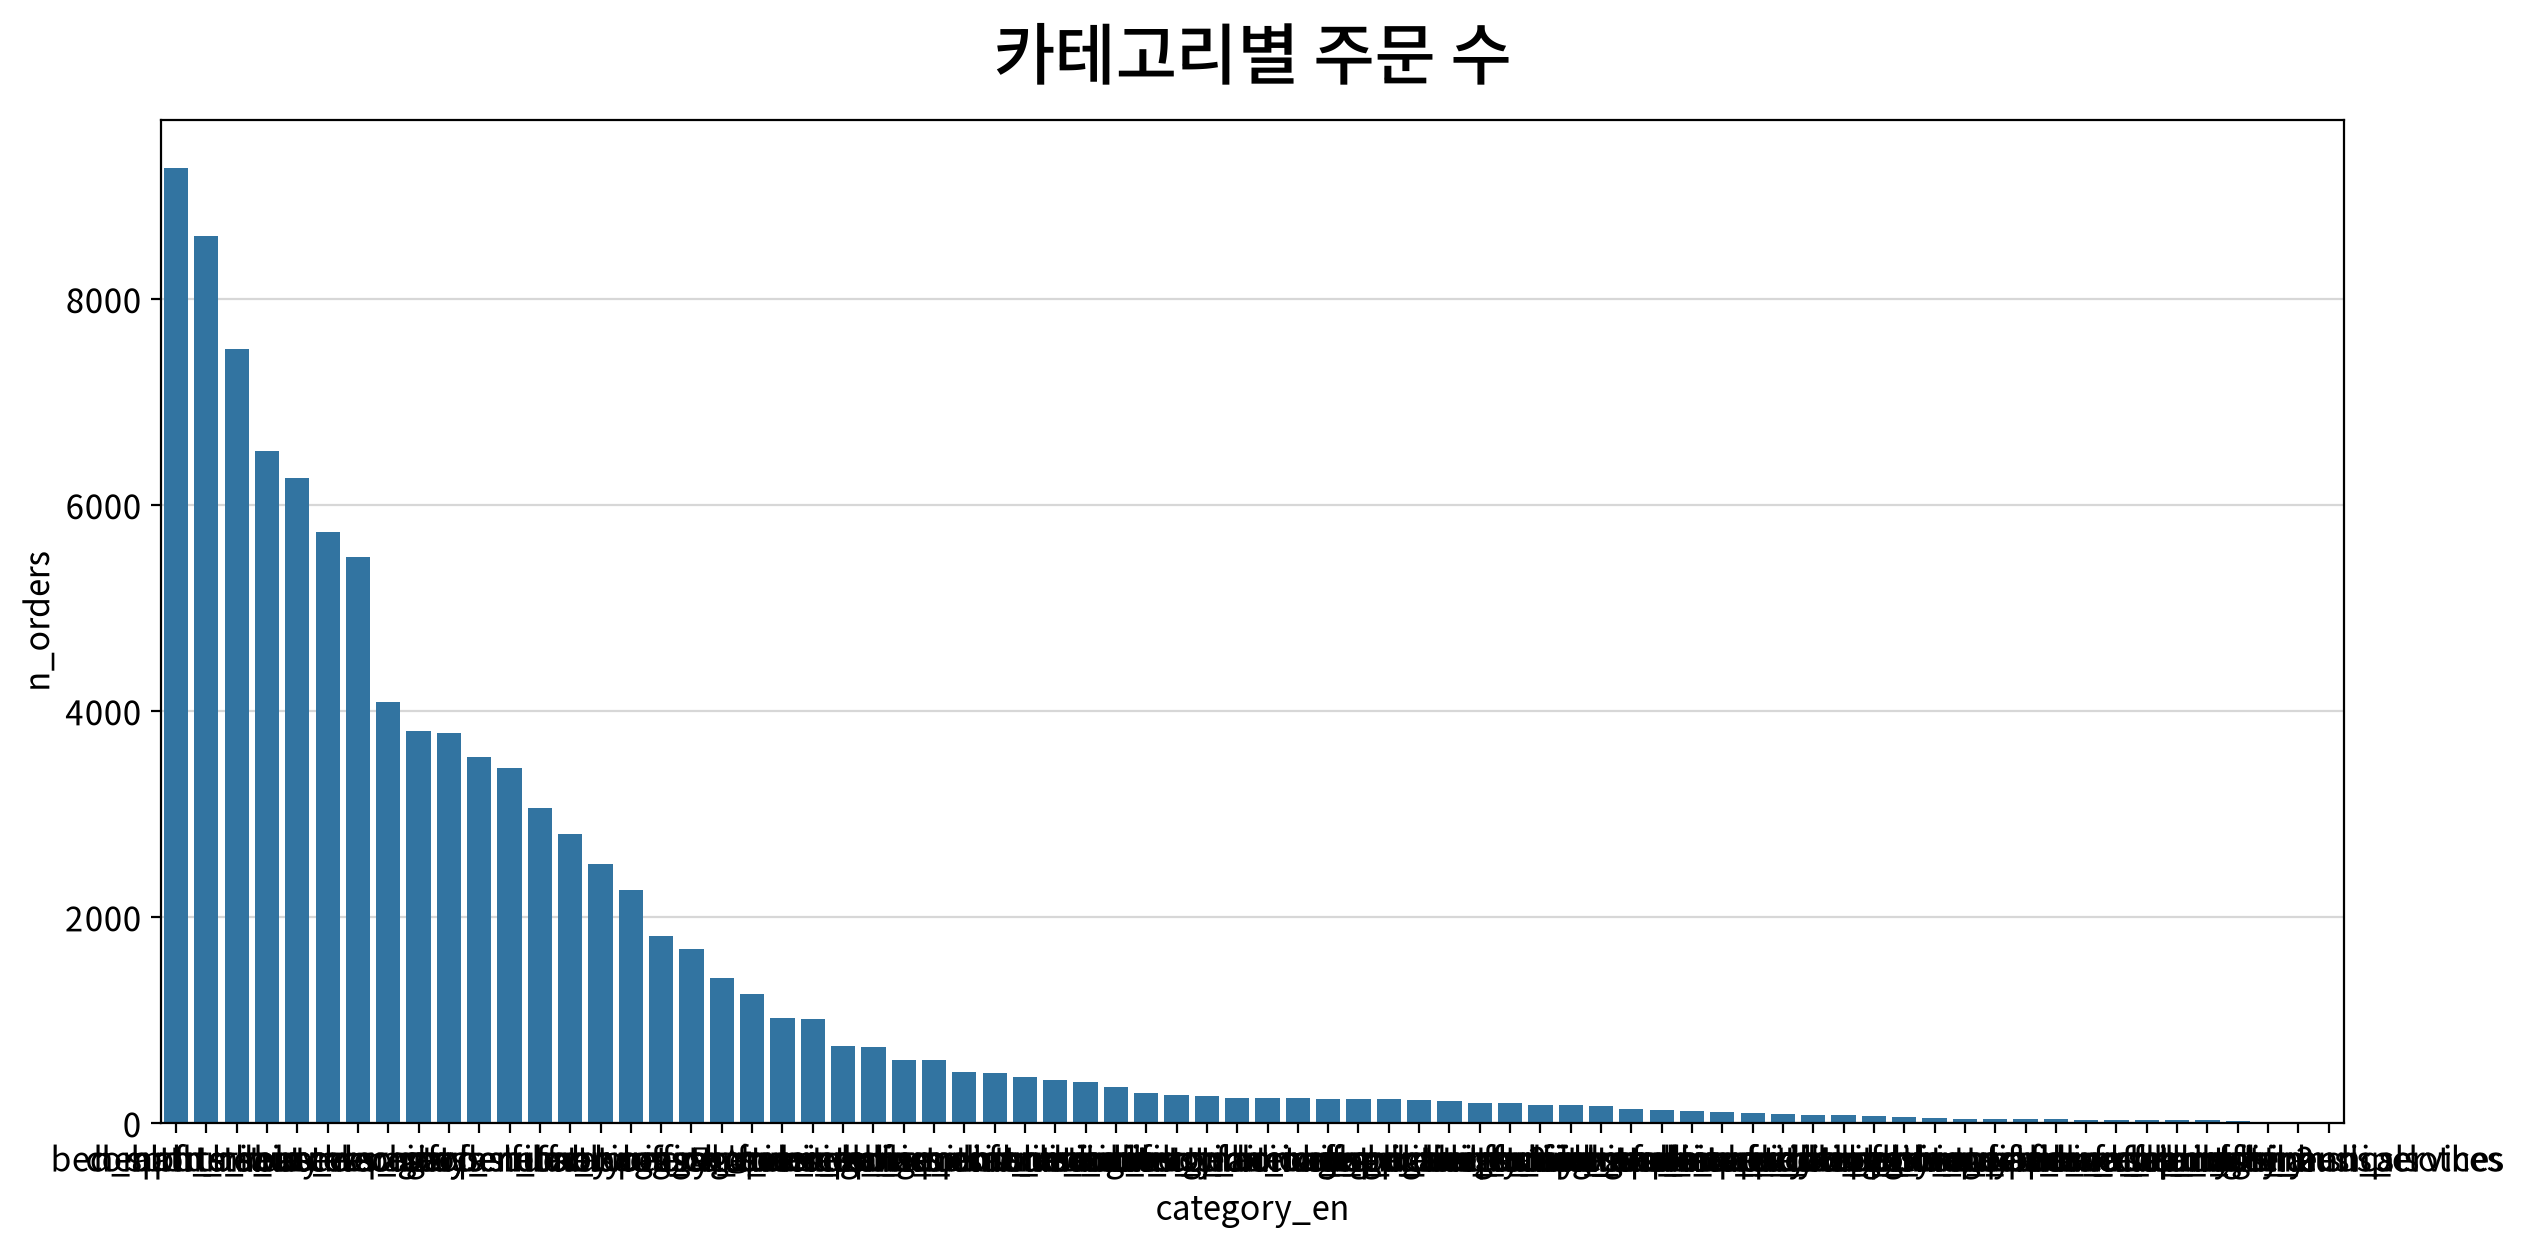

In [21]:
cat_n = (item_base.groupby("category_en")["order_id"].nunique()
                   .sort_values(ascending=False))
cat_share = (cat_n / cat_n.sum()).cumsum()

for p in [0.8, 0.9, 0.95]:
    n_needed = (cat_share <= p).sum() + 1
    print(f"누적 {int(p*100)}% 커버에 필요한 카테고리 수: {n_needed}개")

my_plot.barplot(data=cat_n.reset_index(name="n_orders"),
                 x="category_en", y="n_orders", title="카테고리별 주문 수")
# 실행 확인됨: 80%→16개 / 90%→23개 / 95%→33개
# D-02(상위N 확정)는 Day5, 여기선 후보표만

**위(item_base 기준, 95%→33개)와 아래(master 기준, 95%→32개) 차이**: item_base는 아이템 단위라 한 주문이 여러 카테고리 아이템을 담으면 여러 카테고리에 중복 집계된다. D-02가 그룹핑하려는 건 모델 피처로 쓸 master.category_en(주문당 1개, 대표 카테고리)이므로 아래 셀(master 기준)이 맞는 계산이다. 위 셀은 방법론 오류의 기록으로 남긴다.

누적 80% 커버에 필요한 카테고리 수: 16개
누적 90% 커버에 필요한 카테고리 수: 23개
누적 95% 커버에 필요한 카테고리 수: 32개


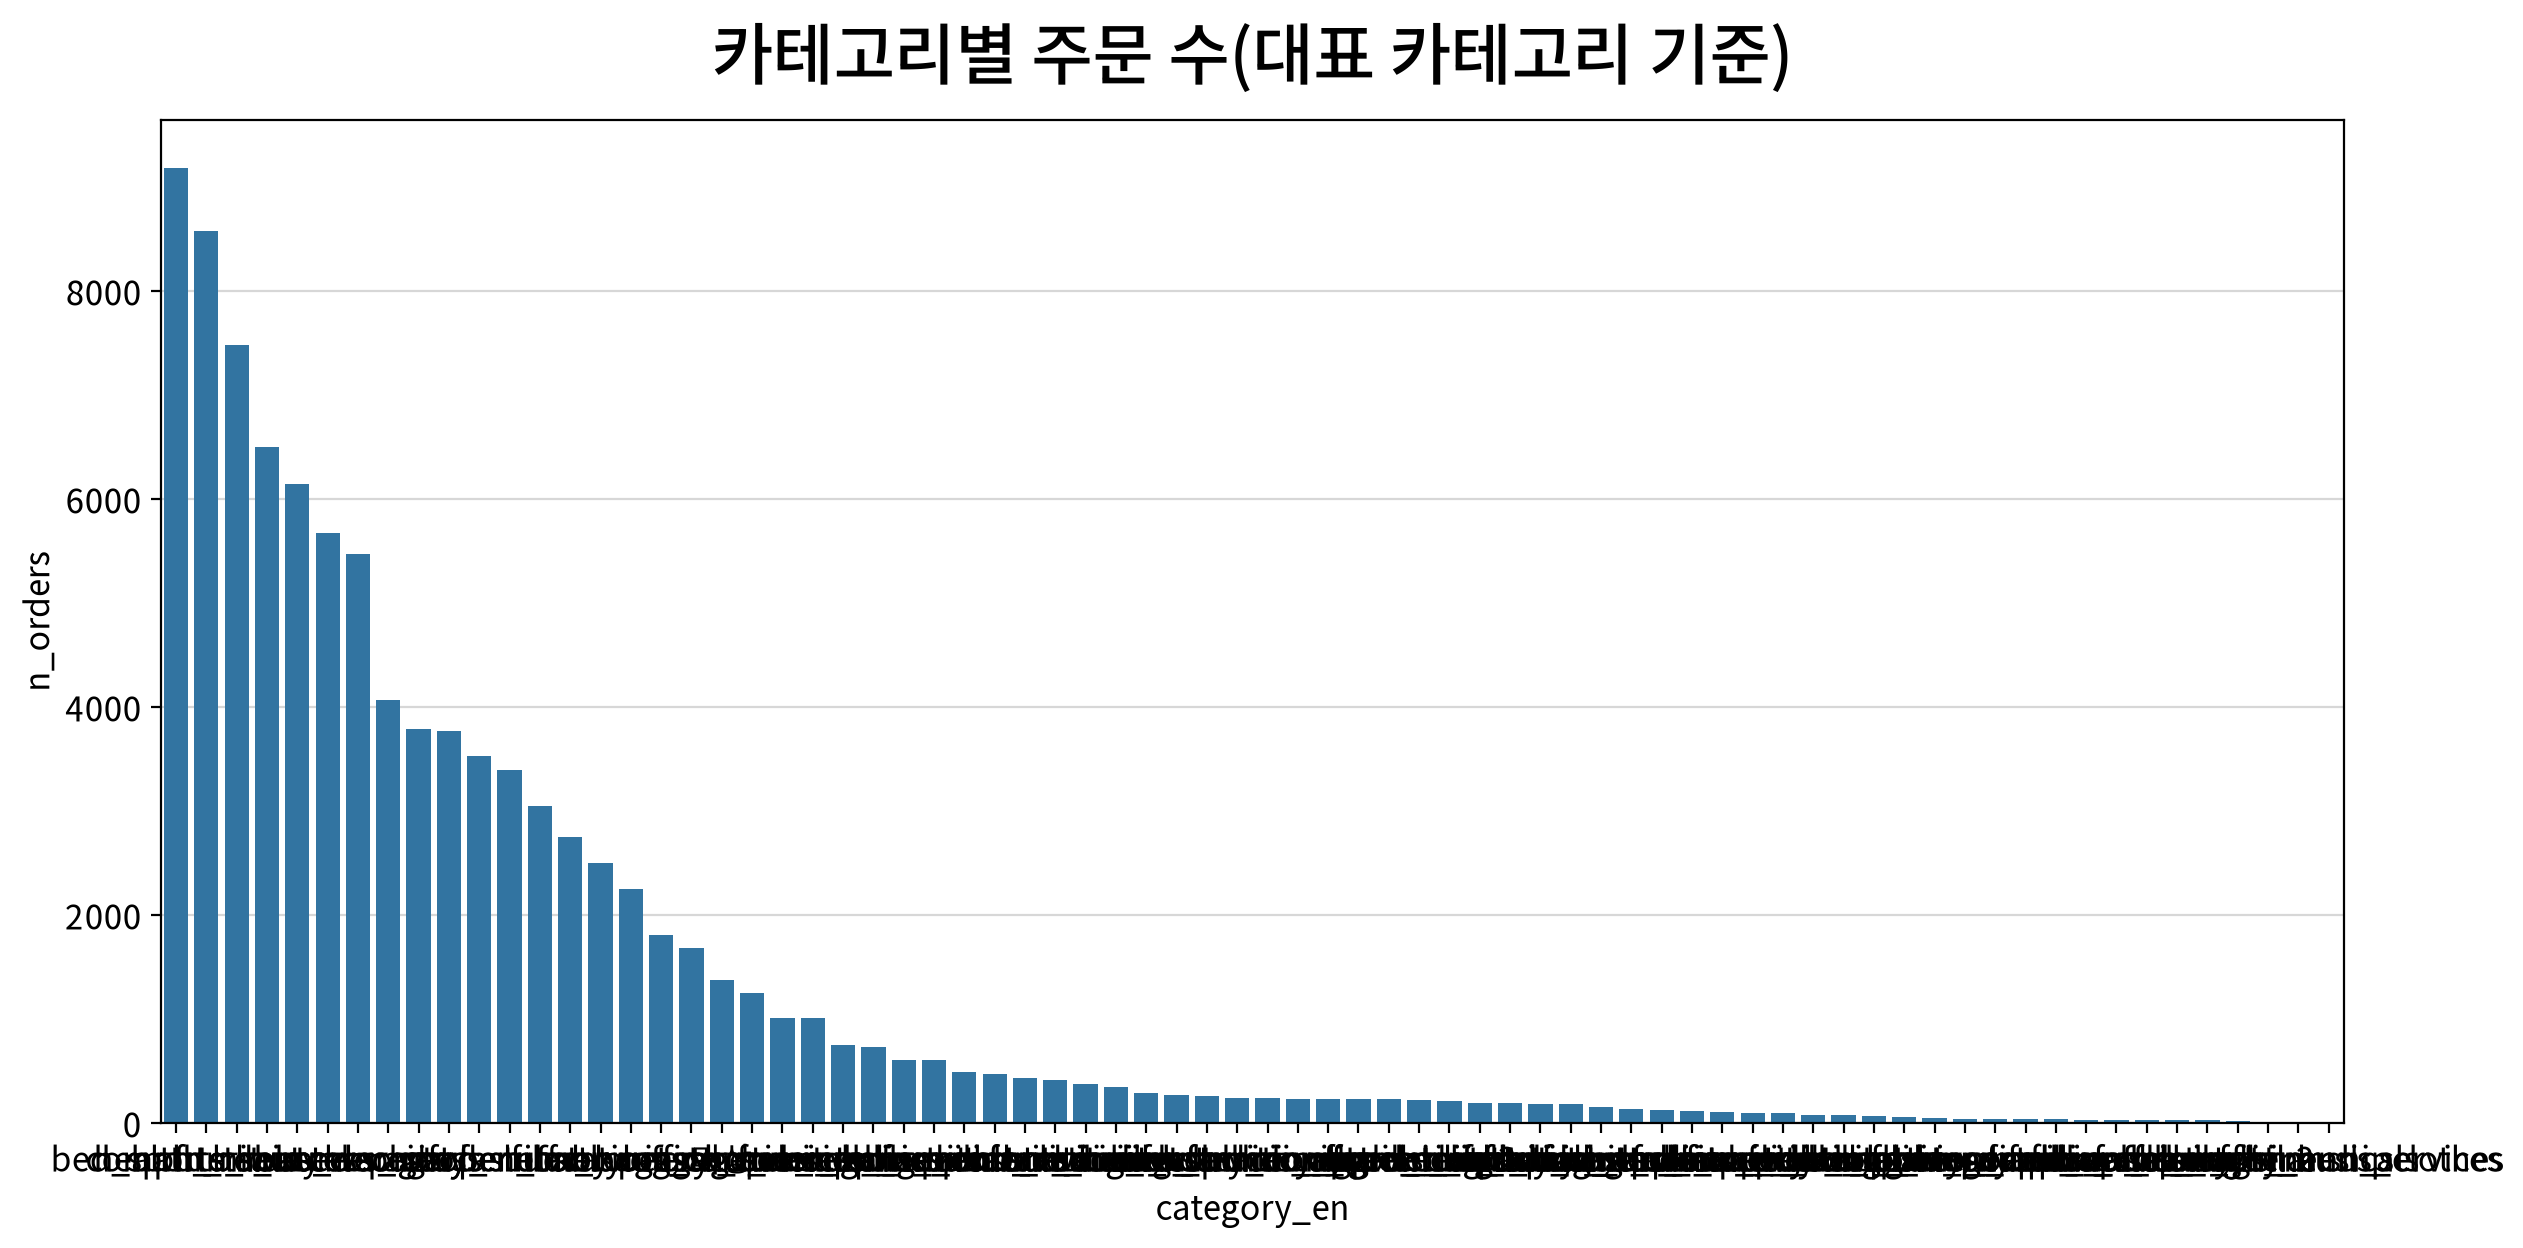

In [22]:
cat_n = master["category_en"].value_counts()   # item_base(아이템 단위) 대신 master(주문 단위 대표 카테고리) 사용
cat_share = (cat_n / cat_n.sum()).cumsum()

for p in [0.8, 0.9, 0.95]:
    n_needed = (cat_share <= p).sum() + 1
    print(f"누적 {int(p*100)}% 커버에 필요한 카테고리 수: {n_needed}개")

my_plot.barplot(data=cat_n.reset_index(name="n_orders").rename(columns={"index": "category_en"}),
                 x="category_en", y="n_orders", title="카테고리별 주문 수(대표 카테고리 기준)")
# item_base 기준(잘못된 이전 버전)과 숫자 비교해서 얼마나 달라졌는지 log.md에 메모